> # **Dermatology Real Problems 🦠**

💡 *Portfolio Data Science Project 3*

---

> #### **Cấu trúc Notebook**
>
> |Phần|Nội dung|Mục đích|
> |---|---|---|
> | **1**  | **Bài toán đặt ra**                             | Hiểu bối cảnh y khoa, ý nghĩa features, target, business/medical objective và xác định tiêu chí thành công.                                                                |
> | **2**  | **Import thư viện**                             | Import các thư viện phục vụ xử lý dữ liệu, visualization, preprocessing, modeling, evaluation và XAI.                                                                      |
> | **3**  | **Khám phá dữ liệu**                            | Hiểu cấu trúc, kích thước, data types, missing values, distributions và class distribution ban đầu.                                                                        |
> | **4**  | **Basic Data Cleaning**                         | Xử lý lỗi logic, format, spelling, duplicates, inconsistent values,...                                                                                                     |
> | **5**  | **EDA**                                         | Tìm patterns, relationships, anomalies và medical signals; đưa ra hypotheses và **đề xuất hướng xử lý** cho các bước tiếp theo.                                            |
> | **6**  | **Feature Engineering**                         | Dựa trên domain knowledge + EDA để tạo các feature có signal mạnh hơn và phản ánh tốt hơn cơ chế của bài toán.                                                             |
> | **7**  | **Train-Test Split & Modeling Pipeline**        | Tách train/test với `stratify`; xây dựng Pipeline gồm preprocessing, optional PCA, sampling và model. Sampling chỉ được thực hiện trên training folds để tránh leakage.    |
> | **8**  | **Baseline & Model Comparison**                 | Xây dựng `DummyClassifier` làm baseline và so sánh nhiều model bằng **Stratified 5-Fold CV** với metric chính phù hợp, ví dụ `F1 Macro`.                                   |
> | **9**  | **Hyperparameter Tuning**                       | Với model tốt nhất, sử dụng `RandomizedSearchCV` → `GridSearchCV` để tìm hyperparameter tối ưu bằng 5-Fold CV.                                                             |
> | **10** | **Final Test Evaluation**                       | Đánh giá một lần trên test set bằng Accuracy, Precision, Recall, F1 Macro/Weighted, per-class metrics, Confusion Matrix, ROC-AUC OVR/OVO, PR Curve và Calibration nếu cần. |
> | **11** | **Model Interpretability / XAI**                | Sử dụng SHAP để phân tích global importance, class-specific importance và local explanations; kết nối kết quả với domain knowledge.                                        |
> | **12** | **Decision Rule / Threshold Tuning (Optional)** | Chỉ thực hiện nếu bài toán cần ưu tiên một hoặc nhiều class; đánh giá ảnh hưởng đến Precision/Recall/F1 của từng class.                                                    |
> | **13** | **Executive Summary**                           | Tổng hợp performance, class-wise performance, key EDA/SHAP insights, limitations và recommendations cho bài toán.                                                          |


---

> ## **Phần 1: Bài toán đặt ra**

* Chẩn đoán phân biệt các bệnh **"erythemato-squamous" (bệnh da ban đỏ – vảy)** là một vấn đề thực sự khó khăn trong da liễu. Tất cả các bệnh này đều có chung các biểu hiện lâm sàng là **ban đỏ (erythema) và bong vảy (scaling)**, với sự khác biệt về biểu hiện lâm sàng là rất nhỏ. Nhóm bệnh này bao gồm **bệnh vảy nến (psoriasis), viêm da tiết bã (seborrheic dermatitis), lichen phẳng (lichen planus), bệnh vảy phấn hồng (pityriasis rosea), viêm da mãn tính (chronic dermatitis), và bệnh vảy phấn đỏ nang lông (pityriasis rubra pilaris)**. Thông thường, **sinh thiết da (biopsy)** là cần thiết để chẩn đoán, nhưng đáng tiếc là các bệnh này cũng có nhiều đặc điểm **mô bệnh học (histopathological features)** giống nhau.

* Trước tiên, bệnh nhân được **đánh giá lâm sàng** dựa trên **12 đặc trưng (features)**. Sau đó, các **mẫu da (skin samples)** được lấy để đánh giá **22 đặc trưng mô bệnh học**. Giá trị của các đặc trưng mô bệnh học được xác định thông qua **phân tích các mẫu da dưới kính hiển vi**.

> #### **Thông tin về giá trị của các đặc trưng**

Trong bộ dữ liệu được xây dựng cho lĩnh vực này, đặc trưng **tiền sử gia đình (family history)** nhận giá trị **1** nếu trong gia đình bệnh nhân đã từng có người mắc **bất kỳ bệnh nào trong số các bệnh này**, và nhận giá trị **0** nếu không có.

Đặc trưng **tuổi (age)** đơn giản biểu thị **tuổi của bệnh nhân**.

Tất cả các đặc trưng còn lại, bao gồm **đặc trưng lâm sàng (clinical features)** và **đặc trưng mô bệnh học (histopathological features)**, được gán một **mức độ (degree)** trong khoảng từ **0 đến 3**.

Cụ thể:

* **0**: đặc trưng **không xuất hiện**.
* **3**: đặc trưng xuất hiện ở **mức độ lớn nhất có thể**.
* **1 và 2**: biểu thị các **mức độ trung gian tương ứng**.

> #### **Ý tưởng khai phá**

- **Phân phối của các thuộc tính:** Khám phá về phân phối của các cột ở trong dataset. Có thể sử dụng `histogram` hoặc `boxplot` để trực quan hóa nhưng thuộc tính (cột) và tìm ra `pattern`, `outliers`.

- **Phân tích tương quan:** Sử dụng ma trận tương quan để tìm ra mối quan hệ giữa các thuộc tính trong dataset. Điều này sẽ giúp phát hiện ra những thuộc tính nào có nhiều mối tương quan với nhau nhất và cũng có thể tìm ra được những thuộc tính mang tín hiệu mạnh trong việc `phân loại class`.

- **Phân tích giá trị còn thiếu (missing values):** Phân tích `missing values` ở trong cột tuổi của bệnh nhân, những giá trị thiếu đó được biểu diễn qua `?`. Cân nhắc tỉ lệ của giá trị thiếu và quyết định xem có cần `impute` giá trị hay không.

- **Phân phối của class:** Phân tích phân phối của `class mục tiêu` ở trong dataset. Có thể sử dụng `bar plot` để trực quan số lượng bệnh nhân mỗi class, quyết định xem data cân bằng hay mất cân bằng.

- **Feature Engineering:** Cân nhắc tạo ra những `feature mới`, mang nhiều tín hiệu hơn trong việc phân loại label. Ví dụ, có thể tạo các biến mang sự kết hợp của biến **bệnh nhân được đánh giá lâm sàng** và **biến về mô bệnh học** `(clinical attributes or histopathological attributes)`.

- **Phát hiện ngoại lai:** Khám phá về giá trị ngoại lai của các cột trong dataset. Các giá trị ngoại lai `(outliers)` có thể gây lệch phân phối và làm ảnh hưởng tới hiệu năng của mô hình. Có thể sử dụng `boxplot` và `scatter plot` để trực quan các phân phối, tìm ra ngoại lai.

---

> 💡 *Ý nghĩa các biến được giải thích chi tiết hơn qua file `Data Dictionary.md` trong cùng folder*

---

> ## **Phần 2: Import thư viện**

In [1]:
# thư viện cơ bản
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tiền xử lí và pipeline dữ liệu
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (train_test_split, StratifiedKFold, RepeatedKFold,
                                     cross_validate, RandomizedSearchCV, GridSearchCV, learning_curve)

# Mô hình Machine Learning
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Xử lí Data mất cân bằng
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipelines
# Metrics đánh giá mô hình
from sklearn.metrics import (precision_score, recall_score, accuracy_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, auc, classification_report, make_scorer)

# Feature Importance / Model Interpretability
import shap
shap.initjs()

e:\DS_projects\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---

> ## **Phần 3: Khám phá dữ liệu**

In [2]:
df = pd.read_csv(r"e:\Portolio DS Project\Project 3 - Dermatology\data\dermatology_database_1.csv")

# Hiển thị 10 dòng đầu
df.head(10)

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3
5,2,3,2,0,0,0,0,0,0,0,...,0,0,2,0,0,0,1,0,41,2
6,2,1,0,2,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,18,5
7,2,2,3,3,3,3,0,2,0,0,...,2,2,3,2,0,0,3,3,57,3
8,2,2,1,0,2,0,0,0,0,0,...,0,0,2,0,0,0,2,0,22,4
9,2,2,1,0,1,0,0,0,0,0,...,0,0,2,0,0,0,2,0,30,4


In [3]:
# Kích thước
print(f"Kích thước (dòng, cột) của dữ liệu: {df.shape}")
print(f"Số dòng: {df.shape[0]}")
print(f"Số cột: {df.shape[1]}")

Kích thước (dòng, cột) của dữ liệu: (366, 35)
Số dòng: 366
Số cột: 35


In [4]:
# Size
print(f"Tổng cell của dataset: {df.size}")

Tổng cell của dataset: 12810


In [5]:
# Thông tin các cột
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                               Non-Null Count  Dtype
---  ------                               --------------  -----
 0   erythema                             366 non-null    int64
 1   scaling                              366 non-null    int64
 2   definite_borders                     366 non-null    int64
 3   itching                              366 non-null    int64
 4   koebner_phenomenon                   366 non-null    int64
 5   polygonal_papules                    366 non-null    int64
 6   follicular_papules                   366 non-null    int64
 7   oral_mucosal_involvement             366 non-null    int64
 8   knee_and_elbow_involvement           366 non-null    int64
 9   scalp_involvement                    366 non-null    int64
 10  family_history                       366 non-null    int64
 11  melanin_incontinence                 366 non-null    int64
 12  eosin

In [6]:
# Thống kê mô tả
df.describe().T

,count,mean,std,min,25%,50%,75%,max
erythema,366.0,2.068306,0.664753,0.0,2.0,2.0,2.0,3.0
scaling,366.0,1.795082,0.701527,0.0,1.0,2.0,2.0,3.0
definite_borders,366.0,1.549180,0.907525,0.0,1.0,2.0,2.0,3.0
itching,366.0,1.366120,1.138299,0.0,0.0,1.0,2.0,3.0
koebner_phenomenon,366.0,0.633880,0.908016,0.0,0.0,0.0,1.0,3.0
polygonal_papules,366.0,0.448087,0.957327,0.0,0.0,0.0,0.0,3.0
follicular_papules,366.0,0.166667,0.570588,0.0,0.0,0.0,0.0,3.0
oral_mucosal_involvement,366.0,0.377049,0.834147,0.0,0.0,0.0,0.0,3.0
knee_and_elbow_involvement,366.0,0.614754,0.982979,0.0,0.0,0.0,1.0,3.0
scalp_involvement,366.0,0.519126,0.905639,0.0,0.0,0.0,1.0,3.0


In [7]:
# Kiểm tra missing values trong cột Age - ?
missing_age = df[df["age"] == "?"]

missing_age["age"].value_counts()

age
?    8
Name: count, dtype: int64

In [8]:
# Kiểm tra missing value tất cả các cột
df.isna().sum()

erythema                               0
scaling                                0
definite_borders                       0
itching                                0
koebner_phenomenon                     0
polygonal_papules                      0
follicular_papules                     0
oral_mucosal_involvement               0
knee_and_elbow_involvement             0
scalp_involvement                      0
family_history                         0
melanin_incontinence                   0
eosinophils_infiltrate                 0
PNL_infiltrate                         0
fibrosis_papillary_dermis              0
exocytosis                             0
acanthosis                             0
hyperkeratosis                         0
parakeratosis                          0
clubbing_rete_ridges                   0
elongation_rete_ridges                 0
thinning_suprapapillary_epidermis      0
spongiform_pustule                     0
munro_microabcess                      0
focal_hypergranu

In [9]:
# Kiểm tra dữ liệu trùng lặp
_ = df.drop_duplicates().shape
if (_ == df.shape):
    print("Bộ dữ liệu không chứa giá trị trùng lặp")
else:
    print(f"Bộ dữ liệu có {df.shape[0] - _[0]} dòng bị trùng lặp")

Bộ dữ liệu không chứa giá trị trùng lặp


In [10]:
# Kiểm tra phân phối của class
df['class'].value_counts()

class
1    112
3     72
2     61
5     52
4     49
6     20
Name: count, dtype: int64

> #### **Tổng quan về bộ dữ liệu**
>
> - Bộ dữ liệu có 366 dòng và 35 cột.
>
> - Có tất cả tổng cộng 12810 cell.
>
> - Tất cả các cột đều biểu diễn giá trị số rời rạc `(discrete number)`, ngoại trừ cột `age` có datatype là `str`.
>
> - Tất cả các cột đều không chứa **missing values**. Ngoại trừ cột `age` có 8 giá trị `?` - **Missing values** trong trường hợp này.
>
> - Tập dữ liệu không chứa duplicated rows `(dòng bị trùng lặp)`
>
> - **Phân phối của biến mục tiêu `(cột class)`:**
>   * Class 1: 112
>   * Class 2: 72
>   * Class 3: 61
>   * Class 4: 52
>   * Class 5: 49
>   * Class 6: 20
>   * **Có thể thấy data bị `imbalanced` khá nhẹ**.
>
> 💡 **Hướng xử lí cho bước tiếp theo - `Basic Data Cleaning`:** Vì missing value `?` chỉ xuất hiện 8/366 lần (xấp xỉ **2% là missing values**). Ta replace nó bằng `np.nan` và hoàn toàn có thể `dropna()`, không gây mất nhiều thông tin. Sau đó convert `str` thành `int`, vì bản chất biến `age` là số, không phải chuỗi.

---

> ## **Phần 4: Basic Data Cleaning**

In [11]:
# replace `?` ở cột age thành NaN
df["age"] = df["age"].replace("?", np.nan)

# dropna() - xóa đi missing value
df.dropna(inplace=True)

# convert dtype cột age sang str
df["age"] = df["age"].astype(int)

# Kết quả
df["age"].info()

<class 'pandas.Series'>
Index: 358 entries, 0 to 365
Series name: age
Non-Null Count  Dtype
--------------  -----
358 non-null    int64
dtypes: int64(1)
memory usage: 5.6 KB


In [12]:
print(f"Kích thước (dòng, cột) của dữ liệu sau khi xóa đi 8 dòng missing value ở cột age: {df.shape}")

Kích thước (dòng, cột) của dữ liệu sau khi xóa đi 8 dòng missing value ở cột age: (358, 35)


---

> ## **Phần 5: EDA (Phân tích khai phá dữ liệu)**

**Cấu trúc phần 5 như sau:**
- Phân tích đơn biến: xem đặc điểm, phân phối các biến (histogram, bar plot, boxplot,...).

- Phân tích đa biến: tìm kiểm pattern, signal giữa `feature` và class mục tiêu. Đồng thời cũng kiểm tra signal giữa các feature - đề xuất `feature engineering`.

- Kiểm định thống kê (nếu có và nếu cần): Kiểm chứng xem sự khác biệt giữa các nhóm có mang **ý nghĩa thống kê hay không**.

- Khi EDA, kèm theo các `markdown cell` nêu ý tưởng và `insights` thu được, đề xuất cho hướng theo tiếp.

> #### **Phần 5.2a: Phân tích đơn biến các biến khám bệnh lâm sàng**

In [13]:
# Tiêu đề in đậm và font chữ cỡ 15, tái sử dụng dễ dàng
font_dict = {"fontsize": 15, "fontweight": 'bold'}

- **Số lượng bệnh nhân kèm theo mức độ của 2 triệu chứng nổi bật nhất qua bài toán - da ban đỏ và bong vảy**

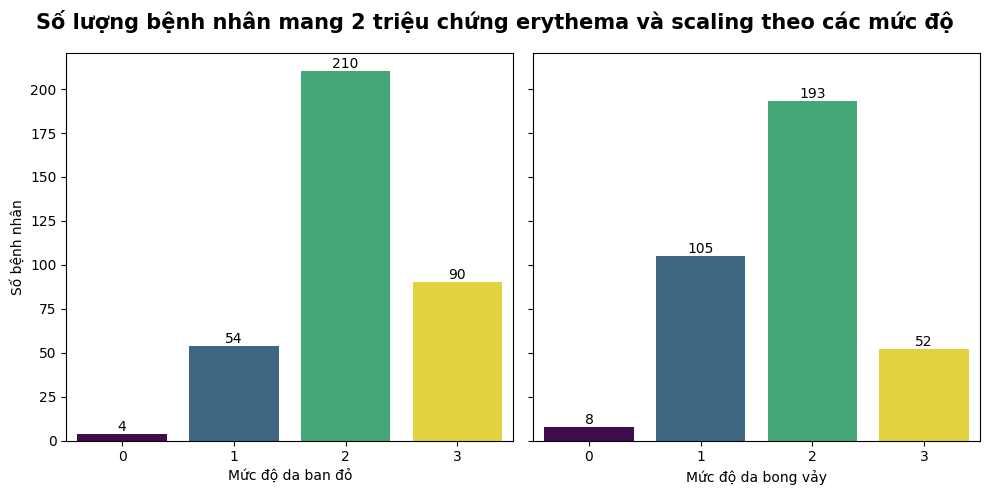

In [14]:
# Khảo sát 2 biến: erythema và scaling
fig, axes = plt.subplots(ncols=2, figsize=(10,5), sharey=True)

_ = ["erythema", "scaling"]
for i in _:
    ax = sns.countplot(data=df,
                       x = i,
                       hue = i,
                       palette = 'viridis',
                       legend = False,
                       ax = axes[_.index(i)])

    for container in ax.containers:
        ax.bar_label(container)

    axes[_.index(i)].set_xlabel("Mức độ da ban đỏ" if i == "erythema" else "Mức độ da bong vảy")
    axes[_.index(i)].set_ylabel("Số bệnh nhân")

fig.suptitle("Số lượng bệnh nhân mang 2 triệu chứng erythema và scaling theo các mức độ", fontsize=15, fontweight='bold')
plt.tight_layout()

---

- **Số lượng bệnh nhân có ranh giới vùng da bị tổn thương theo các mức độ**

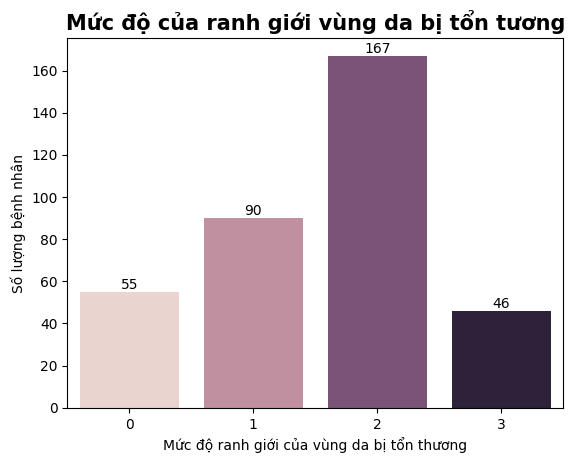

In [15]:
ax = sns.countplot(data=df,
              x = "definite_borders",
              hue = "definite_borders",
              legend = False)

for container in ax.containers:
    ax.bar_label(container)

ax.set_xlabel("Mức độ ranh giới của vùng da bị tổn thương")
ax.set_ylabel("Số lượng bệnh nhân")
ax.set_title("Mức độ của ranh giới vùng da bị tổn tương", fontdict = font_dict)

plt.show()

---

- **Số lượng bệnh nhân có gia đình có người mắc một trong các bệnh thuộc nhóm này**

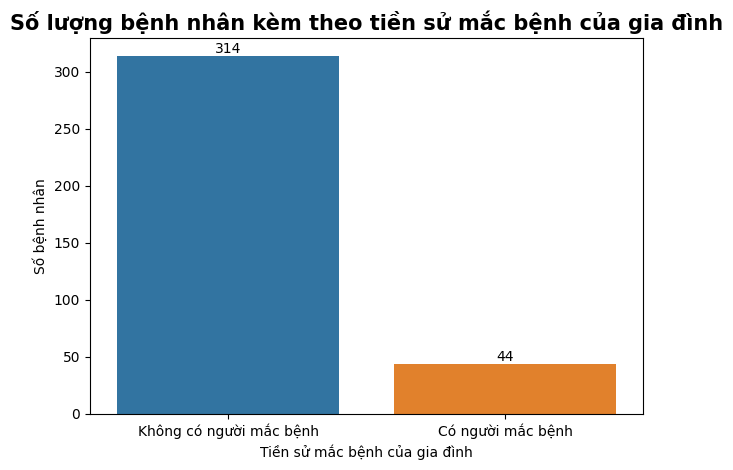

In [16]:
ax = sns.countplot(data=df,
                   x = "family_history",
                   hue = "family_history",
                   legend = False)

for container in ax.containers:
    ax.bar_label(container)

ax.set_xlabel("Tiền sử mắc bệnh của gia đình")
ax.set_xticks(labels=["Không có người mắc bệnh", "Có người mắc bệnh"], ticks=[0,1])
ax.set_ylabel("Số bệnh nhân")
ax.set_title("Số lượng bệnh nhân kèm theo tiền sử mắc bệnh của gia đình", fontdict=font_dict)

plt.tight_layout()

---

- **Phân phối tuổi của bệnh nhân**

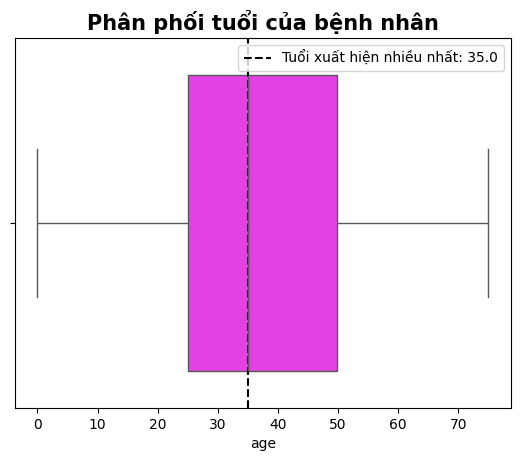

In [17]:
ax = sns.boxplot(data=df,
            x = "age",
            color = "#ff26ff")
ax.set_title("Phân phối tuổi của bệnh nhân", fontdict=font_dict)
ax.axvline(x = df['age'].median(), color = "black", linestyle = "--", label = f"Tuổi xuất hiện nhiều nhất: {df['age'].median()}")
ax.legend()
plt.show()

> #### 💡 **Sơ qua về hồ sơ khám lâm sàng bệnh nhân**
> - *Số lượng bệnh nhân có bệnh da ban đỏ và bong vảy ở mức độ 2 chiếm nhiều nhất*
>
>   * Qua biểu đồ cột khảo sát về số lượng bệnh nhân với 2 bệnh trên theo các mức độ, có thể thấy rằng đa số bệnh nhân đều ở mức độ 2 (Mức độ trung gian - khá nặng). Ngược lại, mức độ nhẹ nhất - mức độ 0 chiếm ít nhất **(dưới 10 người mỗi bệnh)**. Với mức độ nặng nhất, có 90 bệnh nhân mắc ban đỏ và 54 bệnh nhân mắc bong vảy.
>
> - *Ranh giới của da bị thương so với da lành cũng ở mức độ trung gian*
>
>   * Đa số trong các vết liên quan tới dấu hiệu của các nhóm bệnh này, ranh giới giữa da bị thương vưới da lành ở mức độ 2 - Tức là ranh giới khá rõ rệt **(167 bệnh nhân)**. Mức độ nặng nhất chiếm ít nhất **(46 bệnh nhân)**
>
> - *Đa số bệnh nhân có người nhà không có tiền sử **mắc bệnh***
>
>   * Qua biểu đồ khảo sát về tiền sử mắc bệnh của mỗi gia đình bệnh nhân, kết quả cho thấy đa số bệnh nhân có gia đình không có **tiền sử mắc bệnh (chiếm đa số với 314 bệnh nhân)**. Trong khi nhóm ngược lại chỉ có 44 bệnh nhân. 
>
> - *Đa số bệnh nhân khảo sát ở tuổi 35*
>
>   * Qua `boxplot` về phân phối tuổi của bệnh nhân, có thể thấy dải tuổi của bệnh nhân là **25-50** tuổi, đa số chiếm 35 tuổi.
>
> **Tiếp theo, chúng ta sẽ tiếp tục khám phá thêm hồ sơ khám `mô bệnh học`, để tìm ra đích thị đặc điểm mô nào ảnh hưởng tới nhóm bệnh này. Có thể sử dụng ma trận tương quan, nhóm các nhóm theo `groupby()`.**

---

> #### **Phần 5.2b: Phân tích đa biến hồ sơ mô bệnh học**

- **Ma trận tương quan giữa các biến (Hệ số Pearson)**

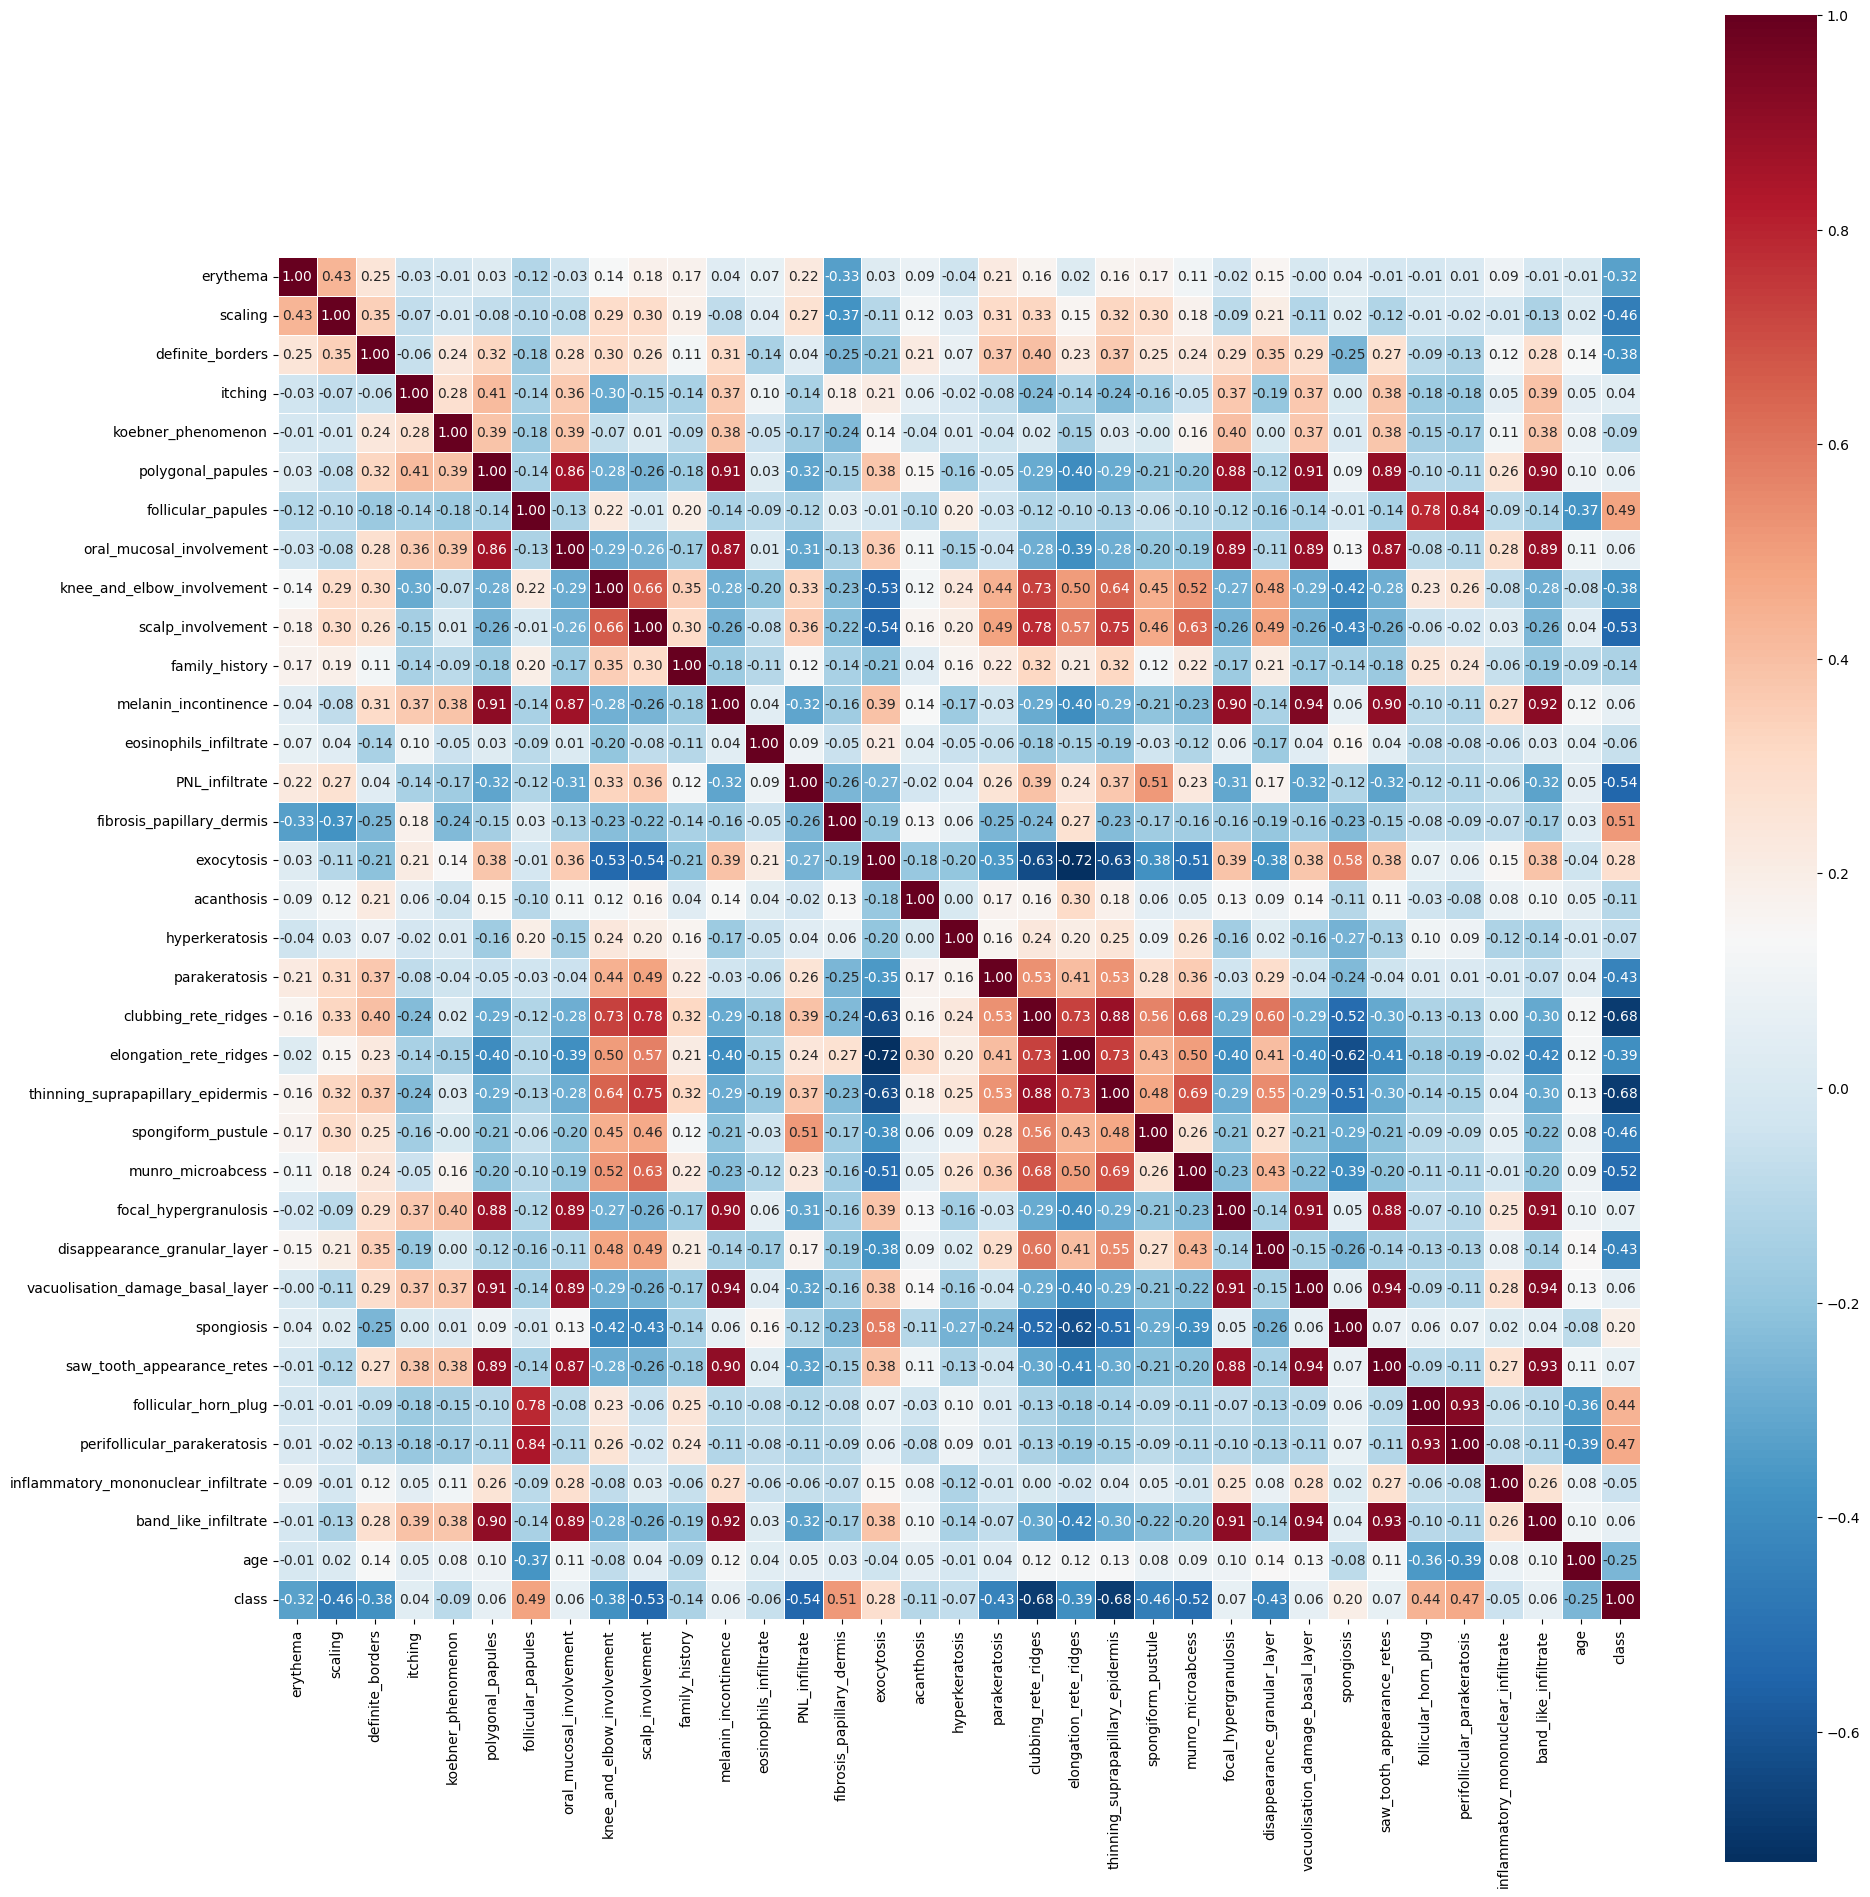

In [18]:
# Ma trận tương quan giữa các biến
corr = df.corr(numeric_only=True)
plt.figure(figsize=(20,20))
sns.heatmap(data=corr,
            annot=True,
            fmt=".2f",
            square=True,
            linewidths=.5,
            cmap="RdBu_r")
plt.tight_layout()

> #### 💡 **Nhận xét tương quan tổng quát**
> ---
> **A. Nhóm biến tương quan thuận chiều mạnh**
>
> **Nhóm 1: `band_like_infiltrate` (Thâm nhiễm dạng dải)**
>
> |Biến 1|Biến 2|Hệ số tương quan **(Pearson)**|
> |---|---|---|
> |`band_like_infiltrate`|polygonal_papules|0.90|
> |`band_like_infiltrate`|oral_mucosal_involvement|0.89|
> |`band_like_infiltrate`|melanin_incontinence|0.92|
> |`band_like_infiltrate`|focal_hypergranulosis|0.91|
> |`band_like_infiltrate`|vacuolisation_damage_basal_layer|0.94|
> |`band_like_infiltrate`|saw_tooth_appearance_retes|0.93|
>
> → **`Ý nghĩa`**: Khi mức độ **thâm nhiễm dạng dải** càng rõ, cũng có xu hướng kéo theo mức độ rõ ràng của đặc điểm `mô bệnh học` sau: 
> * *Sẩn đa giác*
> * *Tổn thương niêm mạc miệng*
> * *Sự mất kiểm soát melanin*
> * *Tăng hạt khu trú*
> * *Không bào hóa và tổn thương lớp đáy*
> * *Hình ảnh răng cưa của các mào biểu bì*
>
> --- 
>
> **Nhóm 2: `polygonal_papules` (Sẩn đa giác)**
>
> |Biến 1|Biến 2|Hệ số tương quan **(Pearson)**|
> |---|---|---|
> |`polygonal_papules`|saw_tooth_appearance_retes|0.89|
> |`polygonal_papules`|vacuolisation_damage_basal_layer|0.91|
> |`polygonal_papules`|focal_hypergranulosis|0.88|
> |`polygonal_papules`|melanin_incontinence|0.91|
> |`polygonal_papules`|oral_mucosal_involvement|0.86|
>
> → **`Ý nghĩa`**: Khi mức độ **Sẩn đa giác** càng rõ, cũng có xu hướng kéo theo mức độ rõ ràng của đặc điểm `mô bệnh học` sau: 
> * *Hình ảnh răng cưa của các mào biểu bì*
> * *Không bào hóa và tổn thương lớp đáy*
> * *Tăng hạt khu trú*
> * *Sự mất kiểm soát melanin*
> * *Tổn thương niêm mạc miệng*
>
> --- 
>
> **Nhóm 3: `follicular_papules` (Sẩn nang lông)**
>
> |Biến 1|Biến 2|Hệ số tương quan **(Pearson)**|
> |---|---|---|
> |`follicular_papules`|perifollicular_parakeratosis|0.84|
> |`follicular_papules`|follicular_horn_plug|0.78|
>
> → **`Ý nghĩa`**: Khi mức độ **Sẩn nang lông** càng rõ, cũng có xu hướng kéo theo mức độ rõ ràng của đặc điểm `mô bệnh học` sau: 
> * *Á sừng quanh nang lông*
> * *Nút sừng nang lông*
>
> --- 
>
> **Nhóm 4: `oral_mucosal_involvement` (Tổn thương niêm mạc miệng)**
>
> |Biến 1|Biến 2|Hệ số tương quan **(Pearson)**|
> |---|---|---|
> |`oral_mucosal_involvement`|saw_tooth_appearance_retes|0.87|
> |`oral_mucosal_involvement`|vacuolisation_damage_basal_layer|0.89|
> |`oral_mucosal_involvement`|focal_hypergranulosis|0.89|
> |`oral_mucosal_involvement`|melanin_incontinence|0.87|
>
> → **`Ý nghĩa`**: Khi mức độ **Tổn thương niêm mạc miệng** càng rõ, cũng có xu hướng kéo theo mức độ rõ ràng của đặc điểm `mô bệnh học` sau: 
> * *Hình ảnh răng cưa của các mào biểu bì*
> * *Không bào hóa và tổn thương lớp đáy*
> * *Tăng hạt khu trú*
> * *Sự mất kiểm soát melanin*
>
> --- 
>
> **Nhóm 5: `melanin_incontinence` (Sự mất kiểm soát melanin)**
>
> |Biến 1|Biến 2|Hệ số tương quan **(Pearson)**|
> |---|---|---|
> |`melanin_incontinence`|saw_tooth_appearance_retes|0.90|
> |`melanin_incontinence`|vacuolisation_damage_basal_layer|0.94|
> |`melanin_incontinence`|focal_hypergranulosis|0.90|
>
> → **`Ý nghĩa`**: Khi mức độ **Sự mất kiểm soát melanin** càng rõ, cũng có xu hướng kéo theo mức độ rõ ràng của đặc điểm `mô bệnh học` sau: 
> * *Hình ảnh răng cưa của các mào biểu bì*
> * *Không bào hóa và tổn thương lớp đáy*
> * *Tăng hạt khu trú*
>
> --- 
>
> **Nhóm 6: Nhóm nhỏ khác: `focal_hypergranulosis` và `vacuolisation_damage_basal_layer`**
>
> |Biến 1|Biến 2|Hệ số tương quan **(Pearson)**|
> |---|---|---|
> |`focal_hypergranulosis`|saw_tooth_appearance_retes|0.88|
> |`focal_hypergranulosis`|vacuolisation_damage_basal_layer|0.91|
> |`vacuolisation_damage_basal_layer`|saw_tooth_appearance_retes|0.94|
>
> → **`Ý nghĩa`**: Khi mức độ **Tăng hạt khu trú** và **Không bào hóa và tổn thương lớp đáy** càng rõ, cũng có xu hướng kéo theo mức độ rõ ràng của đặc điểm `mô bệnh học` sau: 
> * *Hình ảnh răng cưa của các mào biểu bì*
> * *Không bào hóa và tổn thương lớp đáy*

---

> **B. Nhóm biến tương quan nghịch chiều mạnh - trung bình**
>
> **Nhóm 1: `exocytosis` (tế bào viêm di chuyển từ mô liên kết vào lớp biểu bì)**
>
> |Biến 1|Biến 2|Hệ số tương quan **(Pearson)**|
> |---|---|---|
> |`exocytosis`|thinning_of_the_suprapapillary_epidermis|-0.63|
> |`exocytosis`|elongation_of_the_rete_ridges|-0.72|
> |`exocytosis`|clubbing_of_the_rete_ridges|-0.63|
>
> → **`Ý nghĩa`**: Khi mức độ **tế bào viêm di chuyển từ mô liên kết vào lớp biểu bì** càng rõ, cũng có xu hướng làm giảm đi mức độ rõ ràng của đặc điểm `mô bệnh học` sau: 
> * *Mỏng biểu bì trên nhú bì*
> * *Kéo dài các mào biểu bì*
> * *Phì đại dạng dùi trống của các mào biểu bì*
>
> ---
>
> **Nhóm 2: `spongiosis` (phù xốp biểu bì)**
>
> |Biến 1|Biến 2|Hệ số tương quan **(Pearson)**|
> |---|---|---|
> |`spongiosis`|clubbing_of_the_rete_ridges|-0.52|
> |`spongiosis`|elongation_of_the_rete_ridges|-0.62|
> |`spongiosis`|thinning_of_the_suprapapillary_epidermis|-0.51|
>
> → **`Ý nghĩa`**: Khi mức độ **phù xốp biểu bì** càng rõ, cũng có xu hướng làm giảm đi mức độ rõ ràng của đặc điểm `mô bệnh học` sau: 
> * *Phì đại dạng dùi trống của các mào biểu bì*
> * *Kéo dài các mào biểu bì*
> * *Mỏng biểu bì trên nhú bì*

---

- **Kiểm tra signal của biến `mô bệnh học` tới biến mục tiêu - `class`**

> Qua biểu đồ hệ số tương quan, xuất hiện các biến có tương quan thuận chiều lẫn nghịch chiều với `class`, tức là khi mức độ mô bệnh học của biến đó càng rõ rệt, biến mục tiêu `(class)` sẽ thiên về các lớp thấp hơn: 1, 2, 3, và ngược lại.
>
> - **Tương quan thuận chiều**
>
> |Biến|Hệ số tương quan với `class`|
> |---|---|
> |`follicular_papules`|0.49|
> |`fibrosis_papillary_dermis`|0.51|
> |`follicular_horn_plug`|0.44|
> |`perifollicular_parakeratosis`|0.47|
>
> ---
>
> - **Tương quan nghịch chiều**
>
> |Biến|Hệ số tương quan với `class`|
> |---|---|
> |`scalp_involvement`|-0.53|
> |`PNL_infiltrate`|-0.54|
> |`clubbing_rete_ridges`|-0.68|
> |`thinning_suprapapillary_epidermis`|-0.68|
> |`munro_microabcess`|-0.52|

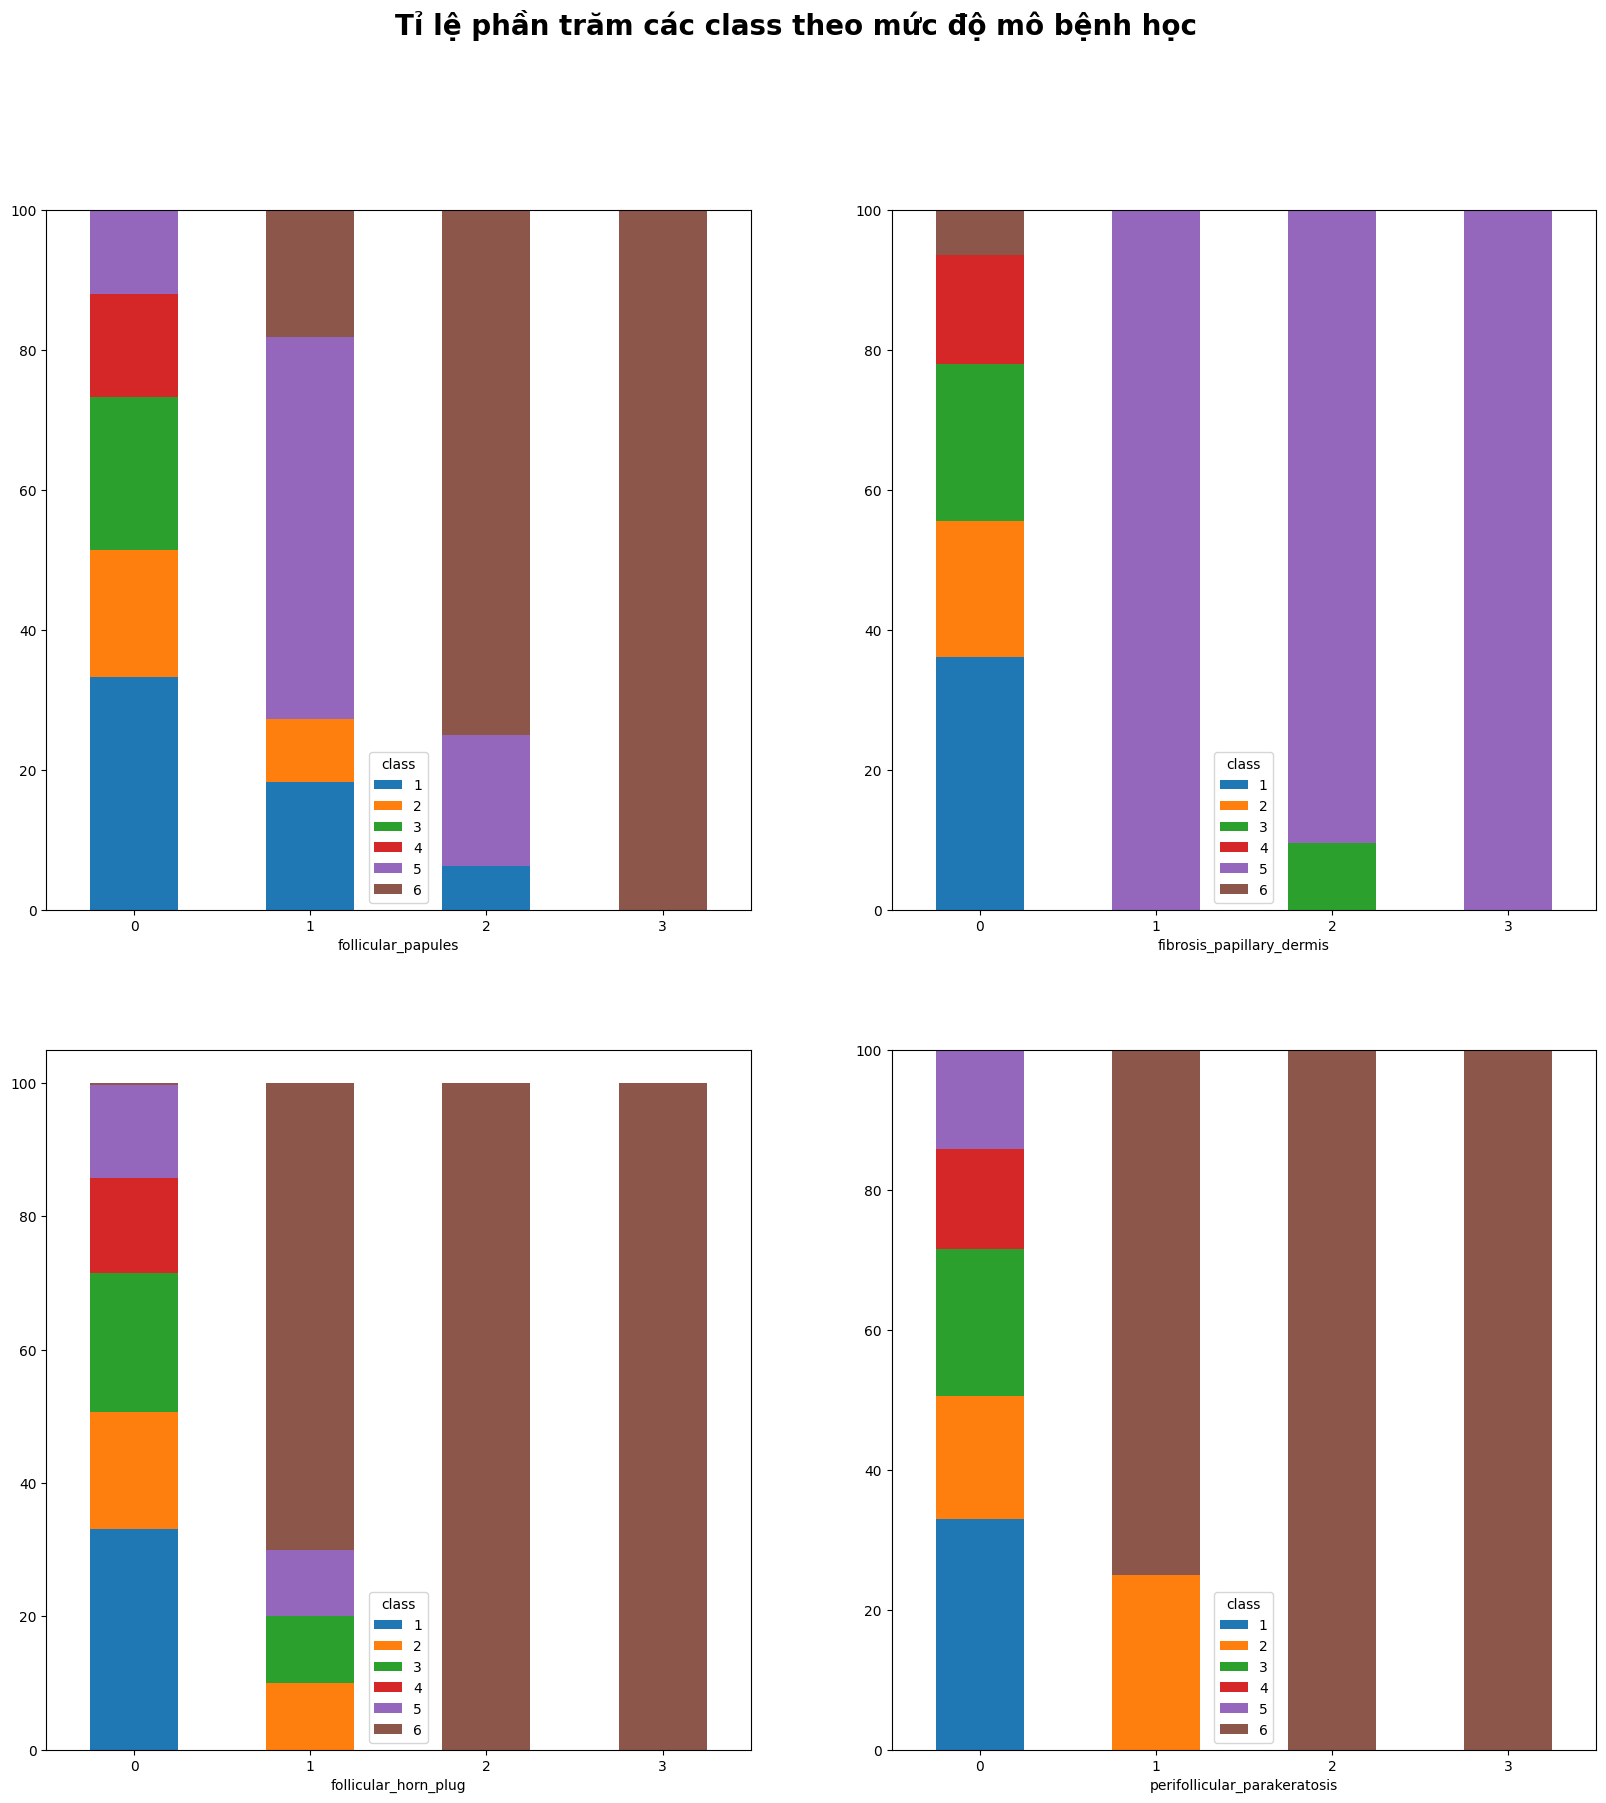

In [19]:
# Khảo sát: Tương quan thuận chiều
fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(20,20))
positive_correlation = ['follicular_papules', 'fibrosis_papillary_dermis', 'follicular_horn_plug', 'perifollicular_parakeratosis']

idx = 0
for i in range(len(positive_correlation) // 2):
    for j in range(len(positive_correlation) // 2):
        
        ct = pd.crosstab(
            df[positive_correlation[idx]],
            df["class"],
            normalize="index"
        ) * 100
        
        ct.plot(
            kind="bar",
            stacked=True,
            ax=axes[i][j]
        )

        axes[i][j].tick_params(axis='x', rotation=0)

        idx += 1

fig.suptitle("Tỉ lệ phần trăm các class theo mức độ mô bệnh học", fontsize=20, fontweight='bold')
plt.show()

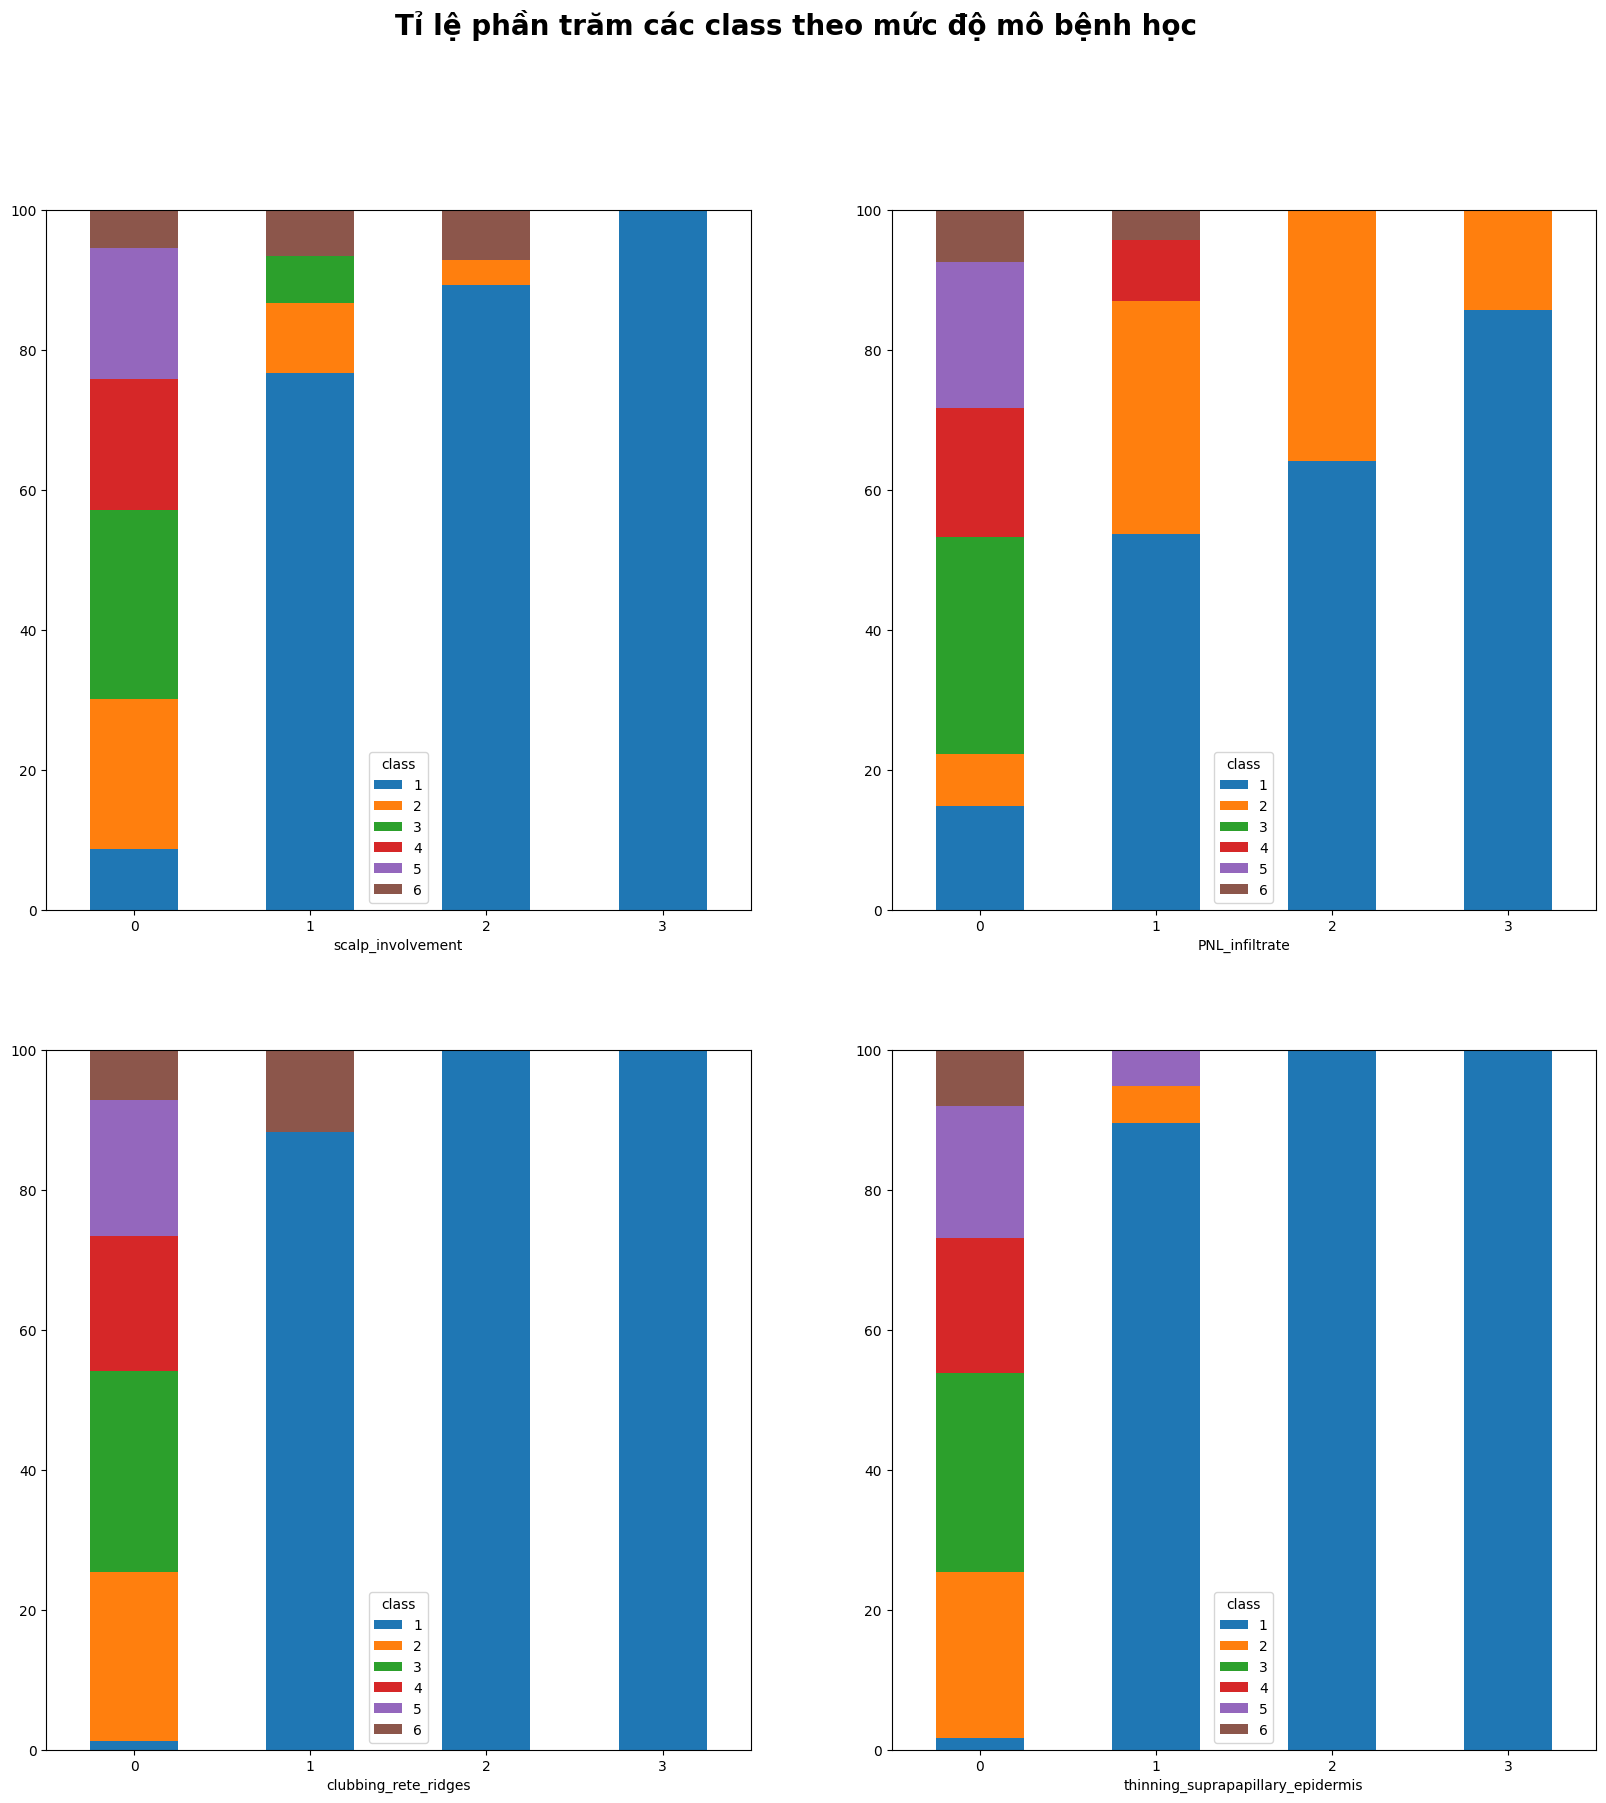

In [20]:
# Khảo sát: Tương quan nghịch chiều
fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(20,20))
negative_correlation = ['scalp_involvement', 'PNL_infiltrate', 'clubbing_rete_ridges', 'thinning_suprapapillary_epidermis']

idx = 0
for i in range(len(negative_correlation) // 2):
    for j in range(len(negative_correlation) // 2):
        
        ct = pd.crosstab(
            df[negative_correlation[idx]],
            df["class"],
            normalize="index"
        ) * 100
        
        ct.plot(
            kind="bar",
            stacked=True,
            ax=axes[i][j]
        )

        axes[i][j].tick_params(axis='x', rotation=0)

        idx += 1

fig.suptitle("Tỉ lệ phần trăm các class theo mức độ mô bệnh học", fontsize=20, fontweight='bold')

plt.show()

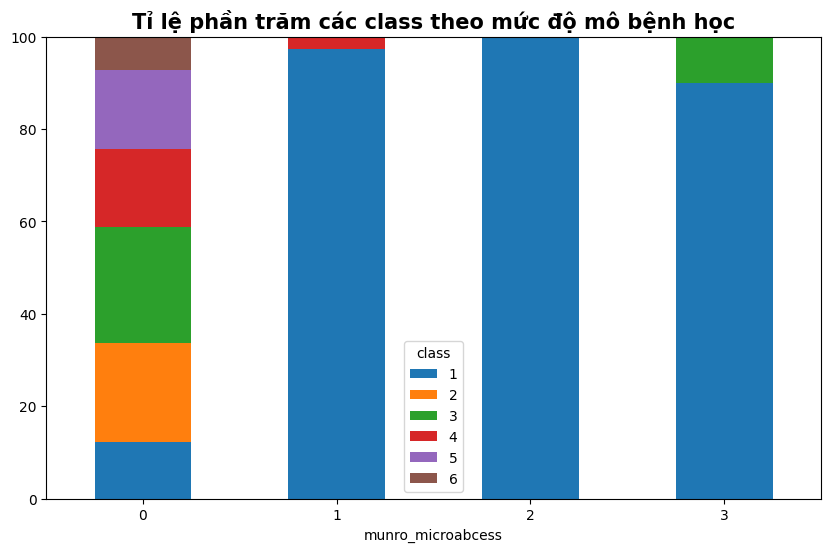

In [21]:
ct = pd.crosstab(
    df['munro_microabcess'],
    df["class"],
    normalize="index"
) * 100
        
ct.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.xticks(rotation=0)
plt.title("Tỉ lệ phần trăm các class theo mức độ mô bệnh học", fontdict=font_dict)
plt.show()

> #### 💡 **Nhận xét signal của các biến `mô bệnh học` với biến mục tiêu - `class`**
>
> - Với các nhóm **follicular_papules, fibrosis_papillary_dermis, follicular_horn_plug, perifollicular_parakeratosis**: Ở *mức độ nhẹ nhất - mức độ 0*, đều cho thấy phân bố giữa các class khá đồng đều. Khi mức độ rõ ràng của *đặc điểm mô bệnh học* tăng lên, tỉ lệ giữa các class giảm dần và có xu hướng thiên về **`class 5, 6`**. Điều này cho thấy *đặc điểm mô bệnh học* của nhóm này là các biến hữu ích, có khả năng phân loại các *class* đầu ra tốt.
>
> - Với các nhóm **scalp_involvement, PNL_infiltrate, clubbing_rete_ridges, thinning_suprapapillary_epidermis, munro_microabcess**: Ở mức độ nhẹ nhất cũng cho thấy sự phân bố đồng đều giữa các class. Khi mức độ rõ ràng của *đặc điểm mô bệnh học* tăng lên, tỉ lệ giữa các class cũng giảm dần và có xu hướng thiên về chủ yếu là **`class 1, 2`**.
>
> → Đề xuất cho bước tiếp theo - ***Feature Engineering***: Cân nhắc tạo ra những `feature mới`, mang nhiều tín hiệu hơn trong việc phân loại label. Ví dụ, có thể tạo các biến mang sự kết hợp của biến **bệnh nhân được đánh giá lâm sàng** và **biến về mô bệnh học** `(clinical attributes or histopathological attributes)`.

---

> ## **Phần 6: Feature Engineering**

> #### 💡 **Phương pháp FE hiệu quả:**
> Hiện tại đang có 7 biến:
>
> - band_like_infiltrate
> - polygonal_papules
> - oral_mucosal_involvement
> - melanin_incontinence
> - focal_hypergranulosis
> - vacuolisation_damage_basal_layer
> - saw_tooth_appearance_retes
>
> Thay vì chỉ để model nhìn từng biến riêng lẻ, ta tạo thêm một biến đại diện cho **mức độ tổng thể của cả nhóm.**
>
> **Ví dụ:**
>
> | Feature                          | Giá trị |
> | -------------------------------- | ------: |
> | band_like_infiltrate             |       3 |
> | polygonal_papules                |       2 |
> | oral_mucosal_involvement         |       2 |
> | melanin_incontinence             |       3 |
> | focal_hypergranulosis            |       1 |
> | vacuolisation_damage_basal_layer |       3 |
> | saw_tooth_appearance_retes       |       2 |
>
> $$
> \begin{aligned}
> \text{GroupScore} &= \frac{3 + 2 + 2 + 3 + 1 + 3 + 2}{7} \\
> &= 2.29
> \end{aligned}
> $$
>
> **Interpretability:** Trung bình, các đặc trưng thuộc nhóm này xuất hiện ở mức **2.29/3**
>
> - Group Score ≈ 0 → Hầu hết các đặc trưng trong nhóm không xuất hiện.
>
> - Group Score ≈ 1 → Mức độ.
>
> - Group Score ≈ 2 → Mức độ tương đối cao.
>
> - Group Score ≈ 3 → Hầu hết các đặc trưng đều rất rõ.
>
> → Đặc biệt, Group Score không phải là một *`luật y khoa`*, mà là một feature được xây dựng từ giả thuyết rằng nhóm biến này cùng phản ánh một pattern. Vì vậy cuối cùng phải kiểm chứng bằng Cross-Validation xem nó có thực sự giúp model hay không.
>
> - Một cách FE hay khác nên được áp dụng: `count_high`
>
> → Feature này cho thấy số lượng đặc trưng đang ở trong nhóm có mức độ rõ ràng cao. Feature này đôi khi rất hữu ích vì nó biểu diễn **breadth / consistency** của pattern, trong khi *mean biểu diễn mức độ trung bình*.

In [22]:
# GroupScore - band_like_infiltrate
band_like_group_cols = [
    "band_like_infiltrate",
    "polygonal_papules",
    "oral_mucosal_involvement",
    "melanin_incontinence",
    "focal_hypergranulosis",
    "vacuolisation_damage_basal_layer",
    "saw_tooth_appearance_retes"
]

# 1. Mức độ tổng thể của pattern
df["band_like_group_score"] = df[band_like_group_cols].mean(axis=1)

# 2. Số lượng đặc trưng xuất hiện ở mức >= 2
df["band_like_high_count"] = (df[band_like_group_cols] >= 2).sum(axis=1)

In [23]:
# polygonal_papules
polygonal_pap_group_cols = [
    "polygonal_papules",
    "saw_tooth_appearance_retes",
    "vacuolisation_damage_basal_layer",
    "focal_hypergranulosis",
    "melanin_incontinence",
    "oral_mucosal_involvement"
]

# 1. Mức độ tổng thể của pattern
df["polygonal_pap_group_score"] = df[polygonal_pap_group_cols].mean(axis=1)

# 2. Số lượng đặc trưng xuất hiện ở mức >= 2
df["polygonal_pap_high_count"] = (df[polygonal_pap_group_cols] >= 2).sum(axis=1)

In [24]:
# follicular_papules
follicular_pap_group_cols = [
    "follicular_papules",
    "perifollicular_parakeratosis",
    "follicular_horn_plug"
]

# 1. Mức độ tổng thể của pattern
df["follicular_pap_group_score"] = df[follicular_pap_group_cols].mean(axis=1)

# 2. Số lượng đặc trưng xuất hiện ở mức >= 2
df["follicular_pap_high_count"] = (df[follicular_pap_group_cols] >= 2).sum(axis=1)

In [25]:
# oral_mucosal_involvement 
oral_group_cols = [
    "oral_mucosal_involvement",
    "saw_tooth_appearance_retes",
    "vacuolisation_damage_basal_layer",
    "focal_hypergranulosis",
    "melanin_incontinence"
]

# 1. Mức độ tổng thể của pattern
df["oral_group_score"] = df[oral_group_cols].mean(axis=1)

# 2. Số lượng đặc trưng xuất hiện ở mức >= 2
df["oral_high_count"] = (df[oral_group_cols] >= 2).sum(axis=1)

In [26]:
# melanin_incontinence
melanin_group_cols = [
    "melanin_incontinence",
    "saw_tooth_appearance_retes",
    "vacuolisation_damage_basal_layer",
    "focal_hypergranulosis"
]

# 1. Mức độ tổng thể của pattern
df["melanin_group_score"] = df[melanin_group_cols].mean(axis=1)

# 2. Số lượng đặc trưng xuất hiện ở mức >= 2
df["melanin_high_count"] = (df[melanin_group_cols] >= 2).sum(axis=1)

In [27]:
# focal_hypergranulosis, vacuolisation_damage_basal_layer
focal_group_cols = [
    "focal_hypergranulosis",
    "saw_tooth_appearance_retes",
    "vacuolisation_damage_basal_layer"
]

# 1. Mức độ tổng thể của pattern
df["focal_group_score"] = df[focal_group_cols].mean(axis=1)

# 2. Số lượng đặc trưng xuất hiện ở mức >= 2
df["focal_high_count"] = (df[focal_group_cols] >= 2).sum(axis=1)

# vacuolisation_damage_basal_layer
vacuo_group_cols = [
    "vacuolisation_damage_basal_layer",
    "saw_tooth_appearance_retes"
]

# 1. Mức độ tổng thể của pattern
df["vacuo_group_score"] = df[vacuo_group_cols].mean(axis=1)

# 2. Số lượng đặc trưng xuất hiện ở mức >= 2
df["vacuo_high_count"] = (df[vacuo_group_cols] >= 2).sum(axis=1)

In [28]:
# exocytosis
exocytosis_group_cols = [
    "exocytosis",
    "thinning_suprapapillary_epidermis",
    "elongation_rete_ridges",
    "clubbing_rete_ridges"
]

# 1. Mức độ tổng thể của pattern
df["exocytosis_group_score"] = df[exocytosis_group_cols].mean(axis=1)

# 2. Số lượng đặc trưng xuất hiện ở mức < 2
df["exocytosis_high_count"] = (df[exocytosis_group_cols] < 2).sum(axis=1)

In [29]:
# spongiosis
spongiosis_group_cols = [
    "spongiosis",
    "clubbing_rete_ridges",
    "elongation_rete_ridges",
    "thinning_suprapapillary_epidermis"
]

# 1. Mức độ tổng thể của pattern
df["spongiosis_group_score"] = df[spongiosis_group_cols].mean(axis=1)

# 2. Số lượng đặc trưng xuất hiện ở mức < 2
df["spongiosis_high_count"] = (df[spongiosis_group_cols] < 2).sum(axis=1)

In [30]:
print(f"Shape sau khi FE: {df.shape}")
print(f"Số lượng feature mới được tạo ra: {df.shape[1] - 35}")

Shape sau khi FE: (358, 53)
Số lượng feature mới được tạo ra: 18


In [31]:
# DataFrame các cột mới
new_features_df = df.iloc[:, 35:]

# Tạo ra list gồm các cột mới
new_cols = new_features_df.columns.to_list()
print(f"Các feature mới sau khi feature engineering: {",\n".join(new_cols)}")

Các feature mới sau khi feature engineering: band_like_group_score,
band_like_high_count,
polygonal_pap_group_score,
polygonal_pap_high_count,
follicular_pap_group_score,
follicular_pap_high_count,
oral_group_score,
oral_high_count,
melanin_group_score,
melanin_high_count,
focal_group_score,
focal_high_count,
vacuo_group_score,
vacuo_high_count,
exocytosis_group_score,
exocytosis_high_count,
spongiosis_group_score,
spongiosis_high_count


> **Gợi ý cho các bước tiếp theo:** Qua *Feature Engineering*, ta đã tạo ra được các biến mang nhiều thông tin hơn giữa `đặc điểm khám lâm sàng` và `đặc điểm khám mô bệnh học`. Nhưng các biến mới được tạo ra chưa chắc đã thật sự tốt cho mô hình sau này. Tới với các phần xây dựng mô hình tiếp theo, ta tạo 2 dataframe:
>
> - 1 dataframe gốc (không có các biến được *Feature Engineering*)
>
> - 1 dataframe mới nhất (chứa các biến đã được *Feature Engineering*)
>
> Cuối cùng, song song huấn luyện mô hình với *2 dataframe này* qua các **Fold CV**. Rồi sẽ quyết định được nên giữ hay loại bỏ các *Feature mới*, và tìm ra biến nào thật sự mang **signal** trong việc phân loại các class.

---

> ## **Phần 7: Train-Test Split & Modeling Pipeline**

In [32]:
# Tạo 2 dataframe đã đề cập ở trên
# dataframe gốc
original_df = df.drop(columns=new_cols)
original_df.head(10)

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3
5,2,3,2,0,0,0,0,0,0,0,...,0,0,2,0,0,0,1,0,41,2
6,2,1,0,2,0,0,0,0,0,0,...,0,0,0,0,0,0,2,0,18,5
7,2,2,3,3,3,3,0,2,0,0,...,2,2,3,2,0,0,3,3,57,3
8,2,2,1,0,2,0,0,0,0,0,...,0,0,2,0,0,0,2,0,22,4
9,2,2,1,0,1,0,0,0,0,0,...,0,0,2,0,0,0,2,0,30,4


In [33]:
# dataframe đã qua Feature Engineering
engineered_df = df
engineered_df.head(10)

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,melanin_group_score,melanin_high_count,focal_group_score,focal_high_count,vacuo_group_score,vacuo_high_count,exocytosis_group_score,exocytosis_high_count,spongiosis_group_score,spongiosis_high_count
0,2,2,0,3,0,0,0,0,1,0,...,0.00,0,0.000000,0,0.0,0,0.75,3,0.75,3
1,3,3,3,2,1,0,0,0,1,1,...,0.00,0,0.000000,0,0.0,0,1.75,1,1.50,1
2,2,1,2,3,1,3,0,3,0,0,...,1.75,3,2.000000,3,2.0,2,0.25,4,0.75,3
3,2,2,2,0,0,0,0,0,3,2,...,0.00,0,0.000000,0,0.0,0,1.50,1,1.50,1
4,2,3,2,2,2,2,0,2,0,0,...,2.25,3,2.666667,3,3.0,2,0.25,4,0.50,3
5,2,3,2,0,0,0,0,0,0,0,...,0.00,0,0.000000,0,0.0,0,0.50,3,0.50,3
6,2,1,0,2,0,0,0,0,0,0,...,0.00,0,0.000000,0,0.0,0,0.75,3,0.50,3
7,2,2,3,3,3,3,0,2,0,0,...,1.50,3,1.333333,2,2.0,2,0.50,3,0.75,3
8,2,2,1,0,2,0,0,0,0,0,...,0.00,0,0.000000,0,0.0,0,0.50,3,0.50,3
9,2,2,1,0,1,0,0,0,0,0,...,0.00,0,0.000000,0,0.0,0,0.75,3,0.50,3


**Đã có 2 dataframe theo yêu cầu, giờ ta chia tập dữ liệu, tạo các pipeline tiền xử lí, modeling qua CV,... như bình thường (làm cho cả 2 dataframe). Ta tạo pipeline hoàn chỉnh với dataframe gốc trước**

---

> #### **Phần 7a: Thực hiện với dataframe gốc**

In [34]:
# Tạo các mô hình
RANDOM_STATE = 42

classifiers_dict = {

    # các tham số class_weight = 'balanced' giúp đánh trọng số cao cho class thiểu số - model đánh giá công bằng hơn
    "Dummy Classifier": DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE), 

    "Logistic Regression": LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE, max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'),

    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'),

    "KNN": KNeighborsClassifier(n_neighbors=5, weights='distance'),

    "Support Vector Classifier": SVC(random_state=RANDOM_STATE, class_weight='balanced', probability=True),

}

In [35]:
# Lấy feature và target
X_og = original_df.drop(columns='class')
y_og = original_df['class']

# Train-Test split
X_og_train, X_og_test, y_og_train, y_og_test = train_test_split(X_og, y_og, random_state=RANDOM_STATE, test_size=0.2, stratify=y_og)

In [36]:
# Tạo bộ tiền xử lí dữ liệu

# Lấy cột numerical
num_og_cols = X_og.select_dtypes(exclude=['str']).columns.to_list()

# Pipeline của các cột numerical
num_og_cols_pipe = Pipeline([
    ("Standard_Scaling", StandardScaler())
])

# preprocessing (Tiền xử lí dữ liệu)
og_preprocessor = ColumnTransformer([
    ("Scaling", num_og_cols_pipe, num_og_cols)
])

In [37]:
# Pipeline cho DataFrame gốc
og_pipelines = {}

for name, model in classifiers_dict.items():
    og_pipelines[name] = Pipeline([
        ("preprocessing", og_preprocessor),
        ("model", model)
    ])

# Kết quả
og_pipelines

{'Dummy Classifier': Pipeline(steps=[('preprocessing',
                  ColumnTransformer(transformers=[('Scaling',
                                                   Pipeline(steps=[('Standard_Scaling',
                                                                    StandardScaler())]),
                                                   ['erythema', 'scaling',
                                                    'definite_borders',
                                                    'itching',
                                                    'koebner_phenomenon',
                                                    'polygonal_papules',
                                                    'follicular_papules',
                                                    'oral_mucosal_involvement',
                                                    'knee_and_elbow_involvement',
                                                    'scalp_involvement',
                                        

---

> #### **Phần 7b: Thực hiện với dataframe đã qua feature engineering**

In [38]:
# Lấy feature và target
X_eng = engineered_df.drop(columns='class')
y_eng = engineered_df['class']

# Train-Test split
X_eng_train, X_eng_test, y_eng_train, y_eng_test = train_test_split(X_eng, y_eng, random_state=RANDOM_STATE, test_size=0.2, stratify=y_eng)

In [39]:
# Tạo bộ tiền xử lí dữ liệu

# Lấy cột numerical
num_eng_cols = X_eng.select_dtypes(exclude=['str']).columns.to_list()

# Pipeline của các cột numerical
num_eng_cols_pipe = Pipeline([
    ("Standard_Scaling", StandardScaler())
])

# preprocessing (Tiền xử lí dữ liệu)
eng_preprocessor = ColumnTransformer([
    ("Scaling", num_eng_cols_pipe, num_eng_cols)
])

In [40]:
# Pipeline cho DataFrame gốc
eng_pipelines = {}

for name, model in classifiers_dict.items():
    eng_pipelines[name] = Pipeline([
        ("preprocessing", eng_preprocessor),
        ("model", model)
    ])

# Kết quả
eng_pipelines

{'Dummy Classifier': Pipeline(steps=[('preprocessing',
                  ColumnTransformer(transformers=[('Scaling',
                                                   Pipeline(steps=[('Standard_Scaling',
                                                                    StandardScaler())]),
                                                   ['erythema', 'scaling',
                                                    'definite_borders',
                                                    'itching',
                                                    'koebner_phenomenon',
                                                    'polygonal_papules',
                                                    'follicular_papules',
                                                    'oral_mucosal_involvement',
                                                    'knee_and_elbow_involvement',
                                                    'scalp_involvement',
                                        

---

> ## **Phần 8: Baseline & Model Comparison**

> ***Lưu ý*: Vì đây là bài toán phân loại đa lớp: Các metrics sẽ có các cách tính trung bình khác nhau qua parameter `average =`**
>
> **Cách truyền tham số `average` sao cho hợp lý với bài toán phân loại đa lớp (Multi-class):**
> 
>|`average =`|Khái niệm|Trường hợp|
>|---|---|---|
>|`None`|**Trả về metrics riêng cho từng class**|Biết model làm tốt hay kém ở lớp nào|
>|`'macro'`|**Tính metrics cho từng class rồi lấy trung bình cộng**|Dataset mất cân bằng, muốn đánh giá công bằng các class. Phù hợp cho các bài toán về y tế, phát hiện gian lận,...|
>|`'weighted'`|**Tính metrics cho từng class rồi lấy trung bình cộng có trọng số theo `support`**|Đánh giá hiệu năng tổng thể theo đúng phân bố dữ liệu|
>|`'micro'`|**Cộng TP, FP, FN rồi tính metrics**|Bài toán multi-class (Nhiều hơn 2 nhãn)|
>
> - **`'macro'`** được chọn cho bài toán phân loại đa lớp này, tại vì mỗi lớp đều mang ý nghĩa y khoa quan trọng, mô hình phải đánh giá `công bằng` thay vì để lớp đa số `(class 1)` làm ảnh hưởng dẫn tới kết quả chung. Ngoài ra, metrics `f1` cũng được ưu tiên hơn các metrics khác. Vì `f1 score` là một metrics công bằng về cả precision lẫn recall, ta mong muốn model ít cảnh báo giả - *tức precision cao* và bắt được nhiều người `positive class` nhất có thể - *tức recall cao* (kèm theo `std` - *độ lệch chuẩn* của metrics mô hình phải thấp - *tức mô hình ổn định qua các fold CV*).
>
> - **`'weighted'`** được chọn làm một cách đánh giá phụ ngoài **`'macro'`**, ta cũng cần xem model đó có hiệu năng thực như thế nào theo đúng phân bố dữ liệu.

In [41]:
# Tạo 5 fold CV
KF = StratifiedKFold(n_splits=5, random_state=RANDOM_STATE, shuffle=True)

# Các metrics để đánh giá qua CV
scoring_dict = {
    "accuracy": "accuracy",

    # macro averaging
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "roc_auc_macro": make_scorer(
        score_func=roc_auc_score,
        response_method='predict_proba',
        multi_class='ovr',
        average='macro'
    ),

    # weighted averaging
    "precision_weighted": "precision_weighted",
    "recall_weighted": "recall_weighted",
    "f1_weighted": "f1_weighted",
    "roc_auc_weighted": make_scorer(
        score_func=roc_auc_score,
        response_method='predict_proba',
        multi_class='ovr',
        average='weighted'
    )
}

In [42]:
# Tạo hàm huấn luyện qua 5 fold CV
def reusable_cv_loop(pipelines, X, y, cv, scoring_dict):
    '''
    Input:

    pipelines: dạng dictionary 
    - key: tên của model
    - value: sklearn.Pipeline, pipeline đầy đủ bao gồm preprocessing, modeling

    X: nhận vào X_train
    y: nhận vào y_train

    cv: Stratified K fold đã được thiết lập

    scoring_dict: dạng dictionary
    - key: tên metrics đánh giá dưới dạng str
    - value: metrics hợp lệ (đúng syntax) qua hàm scoring trong cv

    Output:
    Một DataFrame:
    - cột đầu tiên: tên các model
    - các cột sau: kết quả metrics với mean, std qua các fold CV
    '''
    results = []

    for name, pipeline in pipelines.items():

        # cross validation
        scores = cross_validate(
            estimator = pipeline,
            X = X,
            y = y,
            cv = cv,
            scoring=scoring_dict,
            verbose = 1,
            n_jobs = -1
        )

        # Hiển thị kết quả qua list gồm dictionary
        results.append({

            "Model": name,

            # macro
            "accuracy_mean": scores["test_accuracy"].mean(),
            "accuracy_std": scores["test_accuracy"].std(),

            "precision_macro_mean": scores["test_precision_macro"].mean(),
            "precision_macro_std": scores["test_precision_macro"].std(),

            "recall_macro_mean": scores["test_recall_macro"].mean(),
            "recall_macro_std": scores["test_recall_macro"].std(),

            "f1_macro_mean": scores["test_f1_macro"].mean(),
            "f1_macro_std": scores["test_f1_macro"].std(),

            "roc_auc_macro_mean": scores["test_roc_auc_macro"].mean(),
            "roc_auc_macro_std": scores["test_roc_auc_macro"].std(),

            # weighted
            "precision_weighted_mean": scores["test_precision_weighted"].mean(),
            "precision_weighted_std": scores["test_precision_weighted"].std(),

            "recall_weighted_mean": scores["test_recall_weighted"].mean(),
            "recall_weighted_std": scores["test_recall_weighted"].std(),

            "f1_weighted_mean": scores["test_f1_weighted"].mean(),
            "f1_weighted_std": scores["test_f1_weighted"].std(),

            "roc_auc_weighted_mean": scores["test_roc_auc_weighted"].mean(),
            "roc_auc_weighted_std": scores["test_roc_auc_weighted"].std(),  
        })

    # Chuyển qua DataFrame
    results = pd.DataFrame(results)

    return results

In [43]:
# Huấn luyện các mô hình với dataframe gốc
og_results = reusable_cv_loop(pipelines=og_pipelines,
                              X = X_og_train,
                              y = y_og_train,
                              cv = KF,
                              scoring_dict = scoring_dict)

og_results = og_results.sort_values("f1_macro_mean", ascending=False).reset_index(drop=True)
og_results.style.background_gradient()

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    5.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    4.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    2.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.0s finished


,Model,accuracy_mean,accuracy_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std,roc_auc_macro_mean,roc_auc_macro_std,precision_weighted_mean,precision_weighted_std,recall_weighted_mean,recall_weighted_std,f1_weighted_mean,f1_weighted_std,roc_auc_weighted_mean,roc_auc_weighted_std
0,Random Forest,0.971990,0.030610,0.971071,0.031595,0.970238,0.031314,0.968462,0.034131,0.997820,0.003617,0.975830,0.025724,0.971990,0.030610,0.971965,0.030602,0.998122,0.003039
1,Support Vector Classifier,0.968603,0.020275,0.972047,0.018339,0.969099,0.019306,0.966899,0.021948,0.998693,0.001839,0.974400,0.015725,0.968603,0.020275,0.968107,0.020735,0.998927,0.001480
2,Logistic Regression,0.968482,0.013194,0.966759,0.011892,0.968266,0.013144,0.965165,0.014772,0.998172,0.002128,0.972811,0.009739,0.968482,0.013194,0.968525,0.013229,0.998410,0.001855
3,KNN,0.965033,0.011098,0.966667,0.010410,0.963967,0.010852,0.961375,0.012458,0.995024,0.006942,0.972687,0.006821,0.965033,0.011098,0.965351,0.011104,0.995353,0.006577
4,Decision Tree,0.950938,0.043587,0.952303,0.043108,0.954152,0.040060,0.949632,0.044467,0.972282,0.024216,0.957682,0.037809,0.950938,0.043587,0.951064,0.043289,0.971236,0.025416
5,Dummy Classifier,0.311192,0.006808,0.051865,0.001135,0.166667,0.000000,0.079105,0.001328,0.500000,0.000000,0.096887,0.004182,0.311192,0.006808,0.147755,0.005647,0.500000,0.000000


In [44]:
# Huấn luyện các mô hình với dataframe đã qua FE
eng_results = reusable_cv_loop(pipelines = eng_pipelines,
                               X = X_eng_train,
                               y = y_eng_train,
                               cv = KF,
                               scoring_dict = scoring_dict)

eng_results = eng_results.sort_values("f1_macro_mean", ascending=False).reset_index(drop=True)
eng_results.style.background_gradient()

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.0s finished


,Model,accuracy_mean,accuracy_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std,roc_auc_macro_mean,roc_auc_macro_std,precision_weighted_mean,precision_weighted_std,recall_weighted_mean,recall_weighted_std,f1_weighted_mean,f1_weighted_std,roc_auc_weighted_mean,roc_auc_weighted_std
0,Random Forest,0.968542,0.023258,0.969407,0.025409,0.966071,0.024386,0.965361,0.026052,0.998770,0.002079,0.972243,0.020788,0.968542,0.023258,0.968243,0.023139,0.998912,0.001836
1,Logistic Regression,0.965033,0.011098,0.965005,0.010497,0.964933,0.010805,0.962315,0.012864,0.997913,0.002116,0.969544,0.007646,0.965033,0.011098,0.964831,0.011115,0.998100,0.001814
2,Support Vector Classifier,0.965094,0.022050,0.967976,0.017931,0.965463,0.020175,0.961696,0.024416,0.998947,0.001267,0.973042,0.013846,0.965094,0.022050,0.964450,0.022690,0.999048,0.001022
3,KNN,0.958137,0.020733,0.959192,0.020166,0.958782,0.016718,0.955127,0.020652,0.996467,0.003659,0.964699,0.017469,0.958137,0.020733,0.957931,0.021073,0.996885,0.003124
4,Decision Tree,0.940411,0.052797,0.937290,0.060824,0.938411,0.041423,0.932695,0.053334,0.963408,0.025521,0.948799,0.045111,0.940411,0.052797,0.940916,0.051134,0.965216,0.030507
5,Dummy Classifier,0.311192,0.006808,0.051865,0.001135,0.166667,0.000000,0.079105,0.001328,0.500000,0.000000,0.096887,0.004182,0.311192,0.006808,0.147755,0.005647,0.500000,0.000000


---

> #### **Nhận xét tổng thể**: các mô hình trong pipelines đều vượt mức baseline khá xa (Dummy Classifier) - chứng tỏ các mô hình đã vượt mức baseline tối thiểu cho các metrics để có thể hoạt động tốt, đáng tin cậy.
> 
> - Đối với DataFrame gốc *(Chưa qua Feature Engineering)*: Random Forest và Support Vector Classifier đều cho điểm cao qua các *fold CV* nhưng lại mang độ lệch chuẩn cao hơn các mô hình khác. Cho thấy 2 mô hình này mất ổn định hơn khi so sánh với Logistic Regression hay KNN. 
>
> - Vì vậy, Random Forest và SVC sẽ ít được ưu tiên hơn trong bài toán này bởi tính ổn định của mô hình khi đánh giá. Thay vào đó, `Logistic Regression` sẽ được ưu tiên hơn KNN. Tuy độ lệch chuẩn các metrics của Logistic Regression nhỉnh hơn KNN khoảng **0.002 ~ 0.004**. Khi xét tới một metrics cũng rất quan trọng trong phân loại đa lớp - **ROC-AUC score**, độ lệch chuẩn của KNN lại cao hơn so với `Logistic Regression`.
>
> - Đối với DataFrame đã qua *Feature Engineering*: `Logistic Regression` còn được cải thiện về tính ổn định mô hình đáng kể. 
>  
>   * roc_auc_macro_mean: std giảm **0.000012**
>
>   * roc_auc_weighted_mean: std giảm **0.000041**
> 
> 💡 Cuối cùng, ta chốt dataframe chứa các biến đã được *Feature Engineering* cùng với mô hình ổn định và điểm cũng tương đối cao - `Logistic Regression` gán trọng số `class_weight = 'balanced'`
>
> 💡 Một phương pháp tiếp theo cần thử nghiệm: 
> * `SMOTE` và `ROS` *cho minority class*. Các phương pháp thêm sample cho minority class này có thể sẽ giúp model đưa ra ***Decision Boundary*** tốt hơn, vì vậy chúng ta vẫn cần phải đánh giá qua `cross-validation`.

In [45]:
# Tạo 3 pipeline: gốc, SMOTE và ROS
no_oversampling_pipe = ImbPipelines([
    ("preprocessing", eng_preprocessor),
    ("classifier", LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced', max_iter=1000))
])

SMOTE_pipe = ImbPipelines([
    ("preprocessing", eng_preprocessor),
    ("SMOTE", SMOTE(random_state=RANDOM_STATE)),
    ("classifier", LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced', max_iter=1000))
])

ROS_pipe = ImbPipelines([
    ("preprocessing", eng_preprocessor),
    ("ROS", RandomOverSampler(random_state=RANDOM_STATE)),
    ("classifier", LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced', max_iter=1000))
])

# Pipeline gộp
oversampling_pipelines = {
    "Without Oversampling": no_oversampling_pipe,
    "SMOTE": SMOTE_pipe,
    "ROS": ROS_pipe
}

**Tiếp tục đánh giá qua 5 fold CV**

In [46]:
oversampling_results = reusable_cv_loop(pipelines = oversampling_pipelines,
                                        X = X_eng_train,
                                        y = y_eng_train,
                                        cv = KF,
                                        scoring_dict = scoring_dict)

oversampling_results = oversampling_results.sort_values("f1_macro_mean", ascending=False).reset_index(drop=True)
oversampling_results.style.background_gradient()

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished


,Model,accuracy_mean,accuracy_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std,roc_auc_macro_mean,roc_auc_macro_std,precision_weighted_mean,precision_weighted_std,recall_weighted_mean,recall_weighted_std,f1_weighted_mean,f1_weighted_std,roc_auc_weighted_mean,roc_auc_weighted_std
0,SMOTE,0.964973,0.019274,0.963894,0.023202,0.963504,0.020915,0.962510,0.023005,0.998146,0.002219,0.967357,0.017184,0.964973,0.019274,0.965046,0.019065,0.998320,0.001918
1,Without Oversampling,0.965033,0.011098,0.965005,0.010497,0.964933,0.010805,0.962315,0.012864,0.997913,0.002116,0.969544,0.007646,0.965033,0.011098,0.964831,0.011115,0.998100,0.001814
2,ROS,0.950998,0.020544,0.950388,0.022532,0.949337,0.022324,0.946720,0.024175,0.997405,0.001965,0.956272,0.017290,0.950998,0.020544,0.950712,0.020410,0.997671,0.001641


> **Kết luận:** Cuối cùng ta sẽ lựa chọn Pipeline không chứa phương pháp *Oversampling* do nó đã làm giảm tính ổn định mô hình qua các **fold**. Rất có thể do dataset khá ít sample **(~270 samples)**, nên có thể SMOTE và ROS đã tạo ra `noise`, làm `decision boundary` không ổn định, thậm chí có thể gây **Overfitting** *(quá khớp)*.

---

> ## **Phần 9: Hyperparameter Tuning**

In [47]:
# RandomizedSearchCV với multiclass-compatible solvers
from scipy.stats import loguniform

''' debug
# `l1_ratio` is only valid when penalty='elasticnet' (typically with saga).
# `newton-cg` and `lbfgs` do not support l1/elasticnet penalties.
# Remove `classifier__l1_ratio` so the search space stays valid for all solvers.
'''

param_dist = {
    "classifier__C": loguniform(1e-4, 1e4),
    "classifier__solver": ["lbfgs", "saga", "newton-cg"],
    "classifier__class_weight": [None, "balanced"]
}

random_search = RandomizedSearchCV(
    estimator=no_oversampling_pipe,
    param_distributions=param_dist,
    n_iter=100,
    scoring="f1_macro",
    cv=KF,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
    error_score="raise"
)

# Fit vào tập train
random_search.fit(X_eng_train, y_eng_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__C': <scipy.stats....0019583ED30E0>, 'classifier__class_weight': [None, 'balanced'], 'classifier__solver': ['lbfgs', 'saga', ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can

In [48]:
# Theo dõi hệ số C
searching_results = pd.DataFrame(random_search.cv_results_)

searching_results[
    [
        "param_classifier__C",
        "mean_test_score",
        "std_test_score"
    ]
].sort_values(
    "mean_test_score",
    ascending=False
).style.background_gradient()

,param_classifier__C,mean_test_score,std_test_score
0,0.099156,0.970091,0.019620
82,0.053522,0.970091,0.019620
69,0.057620,0.970091,0.019620
61,0.050225,0.970091,0.019620
43,0.011183,0.969646,0.026498
28,0.014818,0.969646,0.026498
20,0.134426,0.969019,0.015577
63,0.170094,0.966169,0.014556
24,0.144945,0.966169,0.014556
21,0.251911,0.966030,0.019044


In [49]:
print(f"Random Search cv score (f1-macro): {random_search.best_score_}")
print(f"Random Search best params: {random_search.best_params_}")

Random Search cv score (f1-macro): 0.970090589262416
Random Search best params: {'classifier__C': np.float64(0.09915644566638401), 'classifier__class_weight': None, 'classifier__solver': 'newton-cg'}


In [50]:
# GridSearchCV
param_grid = {
    "classifier__C": [0.099155, 0.0992, 0.0993, 0.0994],
    "classifier__solver": ["newton-cg"],
    "classifier__class_weight": [None]
}

grid_search = GridSearchCV(
    estimator=no_oversampling_pipe,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=KF,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# Fit vào tập train
grid_search.fit(X_eng_train, y_eng_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.099155, 0.0992, ...], 'classifier__class_weight': [None], 'classifier__solver': ['newton-cg']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time 

In [51]:
print(f"Grid Search cv score (f1_macro): {grid_search.best_score_}")
print(f"Grid Search best params: {grid_search.best_params_}")

Grid Search cv score (f1_macro): 0.970090589262416
Grid Search best params: {'classifier__C': 0.099155, 'classifier__class_weight': None, 'classifier__solver': 'newton-cg'}


---

> ## **Phần 10: Final Test Evaluation**

In [52]:
# Lấy best classifier
best_clf = grid_search.best_estimator_

# Fit vào tập train
best_clf.fit(X_eng_train, y_eng_train)

# Giá trị dự đoán
y_pred = best_clf.predict(X_eng_test)
y_proba = best_clf.predict_proba(X_eng_test)

# Metrics tổng thể
print(classification_report(y_eng_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        22
           2       1.00      0.92      0.96        12
           3       1.00      1.00      1.00        14
           4       0.91      1.00      0.95        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         4

    accuracy                           0.99        72
   macro avg       0.98      0.99      0.98        72
weighted avg       0.99      0.99      0.99        72



In [53]:
# Kiểm tra overfitting qua Learning Curve với CV và Repeated CV 
# Tạo hàm có thể tái sử dụng learning curve
def reusable_learning_curve(estimator, X, y, cv, scoring, random_state):
    train_sizes, train_scores, val_scores = learning_curve(estimator = estimator,
                                                           X = X,
                                                           y = y,
                                                           cv = cv,
                                                           train_sizes = np.linspace(0.1, 1, 10),
                                                           scoring=scoring,
                                                           random_state=random_state,
                                                           verbose = 1,
                                                           n_jobs = -1)

    return train_sizes, train_scores, val_scores

In [54]:
# Đánh giá với CV + K fold
train_sizes_KF, train_scores_KF, val_scores_KF = reusable_learning_curve(estimator = best_clf,
                                                                         X = X_eng_train,
                                                                         y = y_eng_train,
                                                                         cv = KF,
                                                                         scoring = 'f1_macro',
                                                                         random_state = RANDOM_STATE)

# f1 score trung bình của train, validation
train_mean_KF = train_scores_KF.mean(axis=1)
val_mean_KF = val_scores_KF.mean(axis=1) 

# độ lệch chuẩn f1 score của train, validation 
train_std_KF = train_scores_KF.std(axis=1)
val_std_KF = val_scores_KF.std(axis=1)

# Kết quả
print(f"Trung bình f1_macro qua các fold CV tập train: \n{train_mean_KF}\n")
print(f"Độ lệch chuẩn của f1_macro: \n{train_std_KF}\n")
print()
print(f"Trung bình f1_macro qua các fold CV tập validation: \n{val_mean_KF}\n")
print(f"Độ lệch chuẩn của f1_macro: \n{val_std_KF}\n")

[learning_curve] Training set sizes: [ 22  45  68  91 114 136 159 182 205 228]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.


Trung bình f1_macro qua các fold CV tập train: 
[0.98585859 0.99500891 1.         1.         0.99433095 0.99832391
 0.9934061  0.99089824 0.98305317 0.98223574]

Độ lệch chuẩn của f1_macro: 
[0.02828283 0.00998217 0.         0.         0.00463591 0.00335219
 0.00408013 0.0043383  0.00502461 0.00382008]


Trung bình f1_macro qua các fold CV tập validation: 
[0.8702251  0.9375126  0.96295945 0.95357643 0.94906788 0.95738595
 0.95337071 0.95809713 0.97009059 0.97009059]

Độ lệch chuẩn của f1_macro: 
[0.06826301 0.01546509 0.01706365 0.02921978 0.02623456 0.03347274
 0.01910574 0.01413674 0.01961978 0.01961978]



[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    0.4s finished


In [55]:
# Đánh giá với CV + Repeated K Fold
# Tạo RKF
RKF = RepeatedKFold(n_repeats=5, n_splits=5, random_state=RANDOM_STATE)
train_sizes_RKF, train_scores_RKF, val_scores_RKF = reusable_learning_curve(estimator = best_clf,
                                                                            X = X_eng_train,
                                                                            y = y_eng_train,
                                                                            cv = RKF,
                                                                            scoring = 'f1_macro',
                                                                            random_state = RANDOM_STATE)

# f1 score trung bình của train, validation
train_mean_RKF = train_scores_RKF.mean(axis=1)
val_mean_RKF = val_scores_RKF.mean(axis=1) 

# độ lệch chuẩn f1 score của train, validation 
train_std_RKF = train_scores_RKF.std(axis=1)
val_std_RKF = val_scores_RKF.std(axis=1)

# Kết quả
print(f"Trung bình f1_macro qua các fold CV tập train: \n{train_mean_RKF}\n")
print(f"Độ lệch chuẩn của f1_macro: \n{train_std_RKF}\n")
print()
print(f"Trung bình f1_macro qua các fold CV tập validation: \n{val_mean_RKF}\n")
print(f"Độ lệch chuẩn của f1_macro: \n{val_std_RKF}\n")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.


[learning_curve] Training set sizes: [ 22  45  68  91 114 136 159 182 205 228]
Trung bình f1_macro qua các fold CV tập train: 
[0.99822222 0.99696148 0.99936093 1.         0.99207718 0.99329243
 0.98978377 0.98999154 0.98365355 0.9836832 ]

Độ lệch chuẩn của f1_macro: 
[0.0087093  0.00847617 0.00313079 0.         0.00509364 0.00526628
 0.0067363  0.00552762 0.00619551 0.00683876]


Trung bình f1_macro qua các fold CV tập validation: 
[0.86731238 0.93970126 0.95452805 0.95847607 0.95684771 0.95400844
 0.95706389 0.95914294 0.95906627 0.96322683]

Độ lệch chuẩn của f1_macro: 
[0.10551488 0.03516826 0.02820664 0.02511436 0.02652302 0.02791086
 0.02846659 0.0237182  0.02417875 0.02056539]



[Parallel(n_jobs=-1)]: Done 250 out of 250 | elapsed:    2.0s finished


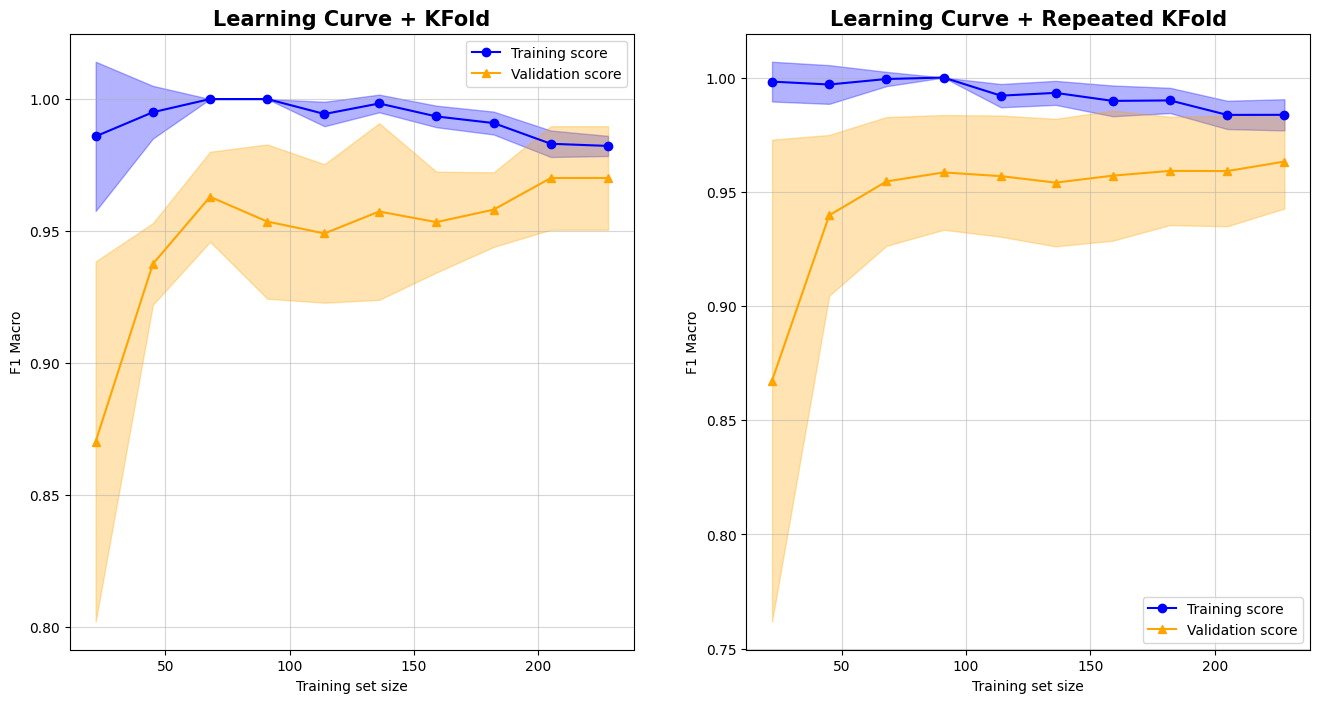

In [56]:
# trực quan hóa qua 2 phương pháp

# K fold
fig, axes = plt.subplots(ncols=2, figsize=(16,8))

axes[0].plot(train_sizes_KF, train_mean_KF, color="blue", marker="o", label="Training score")
axes[0].plot(train_sizes_KF, val_mean_KF, color="orange", marker="^", label="Validation score")

# Tạo vùng độ tin cậy
axes[0].fill_between(train_sizes_KF, train_mean_KF - train_std_KF, train_mean_KF + train_std_KF, alpha=0.3, color="blue")
axes[0].fill_between(train_sizes_KF, val_mean_KF - val_std_KF, val_mean_KF + val_std_KF, alpha=0.3, color="orange")

axes[0].grid(alpha=0.5)
axes[0].set_xlabel("Training set size")
axes[0].set_ylabel("F1 Macro")
axes[0].set_title("Learning Curve + KFold", fontsize = 15, fontweight = 'bold')
axes[0].legend()

# Repeated K Fold
axes[1].plot(train_sizes_RKF, train_mean_RKF, color="blue", marker="o", label="Training score")
axes[1].plot(train_sizes_RKF, val_mean_RKF, color="orange", marker="^", label="Validation score")

# Tạo vùng độ tin cậy
axes[1].fill_between(train_sizes_RKF, train_mean_RKF - train_std_RKF, train_mean_RKF + train_std_RKF, alpha=0.3, color="blue")
axes[1].fill_between(train_sizes_RKF, val_mean_RKF - val_std_RKF, val_mean_RKF + val_std_RKF, alpha=0.3, color="orange")

axes[1].grid(alpha=0.5)
axes[1].set_xlabel("Training set size")
axes[1].set_ylabel("F1 Macro")
axes[1].set_title("Learning Curve + Repeated KFold", fontsize = 15, fontweight = 'bold')
axes[1].legend()

# Kết quả
plt.show()

In [57]:
# Label binarize biến mục tiêu
classes = np.unique(y_eng_train) 

# Label các class
str_classes = ["class 1", "class 2", "class 3", "class 4", "class 5", "class 6"]

# Nhãn thực cho từng observation tập test dưới dạng onehot
y_test_bin = label_binarize(y_eng_test, classes=classes)
y_test_bin

array([[0, 0, 0, 0, 0, 1],
       [0, 0, 0, 1, 0, 0],
       [0, 0, 0, 1, 0, 0],
       [0, 1, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0],
       [0, 0, 1, 0, 0, 0],
       [0, 0, 0, 1, 0, 0],
       [1, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0],
       [0, 0, 1, 0, 0, 0],
       [1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0],
       [0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 1, 0],
       [0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 1],
       [1, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0],
       [1, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0],
       [0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0],
       [1, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1],
       [0, 1, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0],
       [1, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 1],
       [1, 0, 0, 0, 0, 0],
 

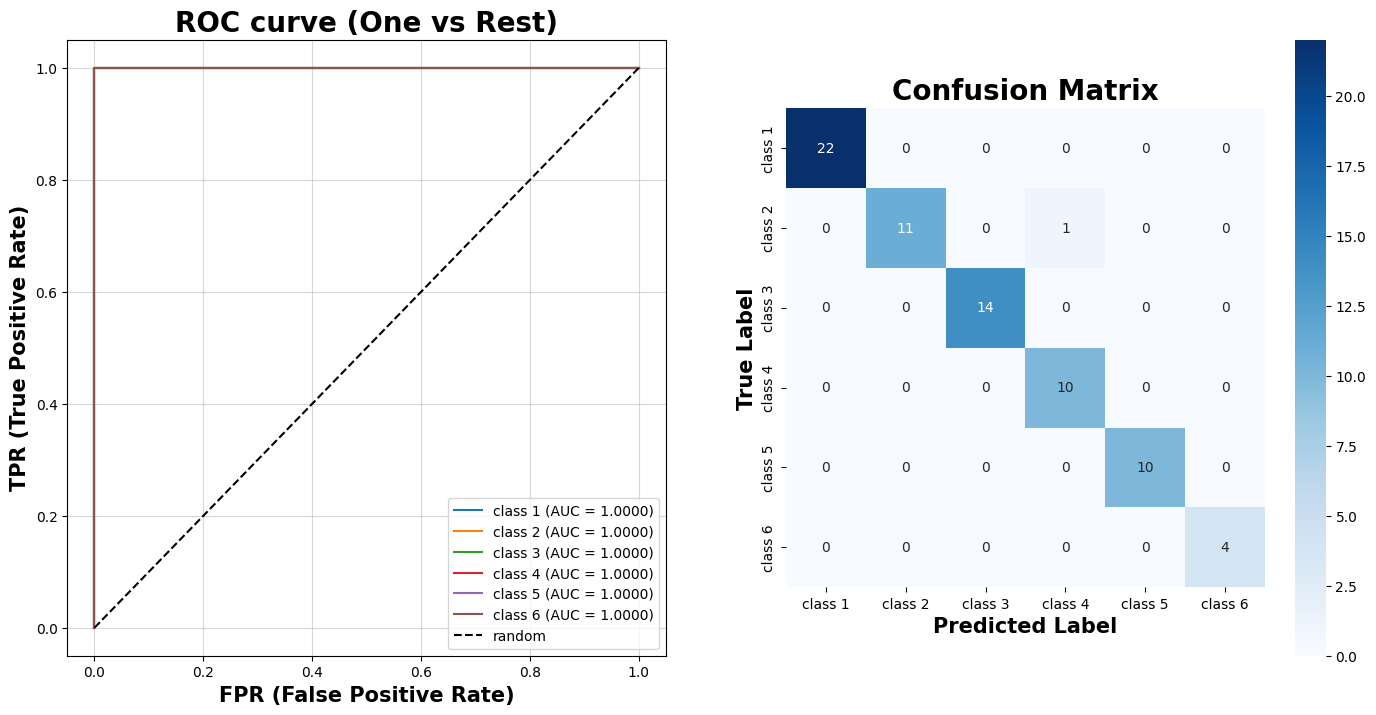

In [58]:
fig, axes = plt.subplots(ncols=2, figsize=(17,8))

# ROC curve
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])

    # Trực quan
    axes[0].plot(fpr, tpr, label=f"{str_classes[i]} (AUC = {auc(fpr, tpr):.4f})")

axes[0].plot([0,1], [0,1], linestyle = "--", color = 'black', label = "random")
axes[0].set_xlabel("FPR (False Positive Rate)", fontsize=15, fontweight='bold')
axes[0].set_ylabel("TPR (True Positive Rate)", fontsize=15, fontweight='bold')
axes[0].set_title("ROC curve (One vs Rest)", fontweight='bold', fontsize=20)
axes[0].grid(alpha=0.5)
axes[0].legend()

# Ma trận nhầm lẫn
cm = confusion_matrix(y_eng_test, y_pred)

# Trực quan
sns.heatmap(cm, fmt=".0f", annot=True, square=True, cmap="Blues", ax = axes[1])
axes[1].set_xlabel("Predicted Label", fontsize=15, fontweight='bold')
axes[1].set_xticks(ticks=[0.5,1.5,2.5,3.5,4.5,5.5], labels= str_classes)
axes[1].set_ylabel("True Label", fontsize=15, fontweight='bold')
axes[1].set_yticks(ticks=[0.5,1.5,2.5,3.5,4.5,5.5], labels= str_classes)

axes[1].set_title("Confusion Matrix", fontsize=20, fontweight='bold')

# Kết quả
plt.show()

> #### 💡 **Insights thu được:**
>
> **1. classification report:**
>
> |averaging|precision|recall|f1|
> |---|---|---|---|
> |macro|0.98|0.99|0.98|
> |weighted|0.99|0.99|0.99|
>
> → **Nhận xét tổng thể hiệu năng của mô hình:**
> - Với 3 điểm precision, recall, f1 theo tham số `macro` ở mức **0.98-0.99**, mô hình hiện tại đang thực hiện tốt nhiệm vụ đánh giá công bằng `metrics` các class dù có sự *mất cân bằng class (class imbalanced) nhẹ*. Với precision, recall đều cao, model đang chứa ít rủi ro cảnh báo giả một người bị phân loại vào sai lớp, model cũng đang bắt được đúng `class` mà người đó thực sự thuộc về.
>
> - Với 3 điểm trên theo tham số `weighted` **(0.99)**, tức model tính metrics nhưng nhân với trọng số `support`.Theo đúng như *phân bố class (class distribution)* với hiện tượng mất cân bằng nhẹ - *thiên về class 1-2*, model hiện tại cũng đang phân loại khá tốt, các `metrics` đánh giá đều đi với *pattern thật* của các class → **Cho thấy model học tốt từ dữ liệu.**
>
> **2. Nhận xét Overfitting**
>
> → **Nhận xét learning curve với 5 fold CV:**
>
> - Với *Dermatology dataset* với khá ít sample hiện tại, model tồn tại nguy cơ bị quá khớp dữ liệu, hay còn được gọi là hiện tượng *Overfitting*. Dấu hiệu nhận biết hiện tượng này xảy ra đó là khi ta theo dõi điểm số đạt được của 2 đường `training` và `validation` qua các cột mốc sample dữ liệu và đồng thời qua các *fold CV*, đường `validation` thấp hơn `training`. Điều này có thể được hiểu đơn giản như sau: 
>   * `Training` cao hơn hẳn so với `validation`: tức model học tốt từ tập train, nhưng lại thất bại ở tập xác thực.
>
>   * Suy luận tương tự với hiện tượng *Underfitting* (thiếu khớp): training và validation đều thấp, cho thấy model học kém từ tập train nên cũng kém ở tập xác thực.
>
> - Với dataset hiện tại: Qua **5 fold CV** và các cột mốc sample được lấy ra để huấn luyện tăng dần lên, `validation` cho thấy xu hướng hội tụ cùng với `training` và độ biến động của `f1 score` cũng giảm dần khi sample tăng lên. Điều này cho thấy model đang đạt được sự ổn định nhất định qua các fold CV **(không tiềm ẩn nguy cơ Overfitting).**
>
> - Nhưng 5 fold CV cũng chỉ chia 1 lần qua các fold. Vì vậy khi 1 fold được **shuffle** các sample, score cũng có khả năng thay đổi. Một cách chia khách quan hơn mà ta có thể áp dụng đó chính là `Repeated K Fold`.
>
> - Với biểu đồ RKF như trên, khi model học được các sample khó hơn khi shuffle các lần split và lặp lại nhiều lần, model vẫn đang giữ khả năng phân loại tốt, tín hiệu tốt đó được thể hiện qua 2 đường `training` và `validation` khá gần nhau sau toàn quá trình.


---

> ## **Phần 11: Model Interpretability / XAI**

In [59]:
# Lấy ra bộ tiền xử lí
eng_preprocessor = best_clf.named_steps["preprocessing"]

# Transform X_eng_test
X_eng_test_processed = eng_preprocessor.transform(X_eng_test)

In [60]:
# Lấy feature_names
feature_names = eng_preprocessor.get_feature_names_out()

# Xóa tiền tố 'Scaling__' ở tên biến
feature_names = [name.replace("Scaling__", "") for name in feature_names]

# Kết quả
print(f"Tên các feature để đưa vào SHAP: {",\n".join(feature_names)}")

Tên các feature để đưa vào SHAP: erythema,
scaling,
definite_borders,
itching,
koebner_phenomenon,
polygonal_papules,
follicular_papules,
oral_mucosal_involvement,
knee_and_elbow_involvement,
scalp_involvement,
family_history,
melanin_incontinence,
eosinophils_infiltrate,
PNL_infiltrate,
fibrosis_papillary_dermis,
exocytosis,
acanthosis,
hyperkeratosis,
parakeratosis,
clubbing_rete_ridges,
elongation_rete_ridges,
thinning_suprapapillary_epidermis,
spongiform_pustule,
munro_microabcess,
focal_hypergranulosis,
disappearance_granular_layer,
vacuolisation_damage_basal_layer,
spongiosis,
saw_tooth_appearance_retes,
follicular_horn_plug,
perifollicular_parakeratosis,
inflammatory_mononuclear_infiltrate,
band_like_infiltrate,
age,
band_like_group_score,
band_like_high_count,
polygonal_pap_group_score,
polygonal_pap_high_count,
follicular_pap_group_score,
follicular_pap_high_count,
oral_group_score,
oral_high_count,
melanin_group_score,
melanin_high_count,
focal_group_score,
focal_high_count,


In [61]:
# Tạo SHAP explainer cho classifier bên trong pipeline (dùng predict_proba)
classifier = best_clf.named_steps["classifier"]

# cung cấp dữ liệu đã được tiền xử lí làm background để masker được xác định đúng
explainer = shap.Explainer(classifier.predict_proba, X_eng_test_processed)

# Tính shap values (cú pháp hiện hành: gọi explainer lên dữ liệu)
shap_values = explainer(X_eng_test_processed)

> #### **Global Explainability SHAP**

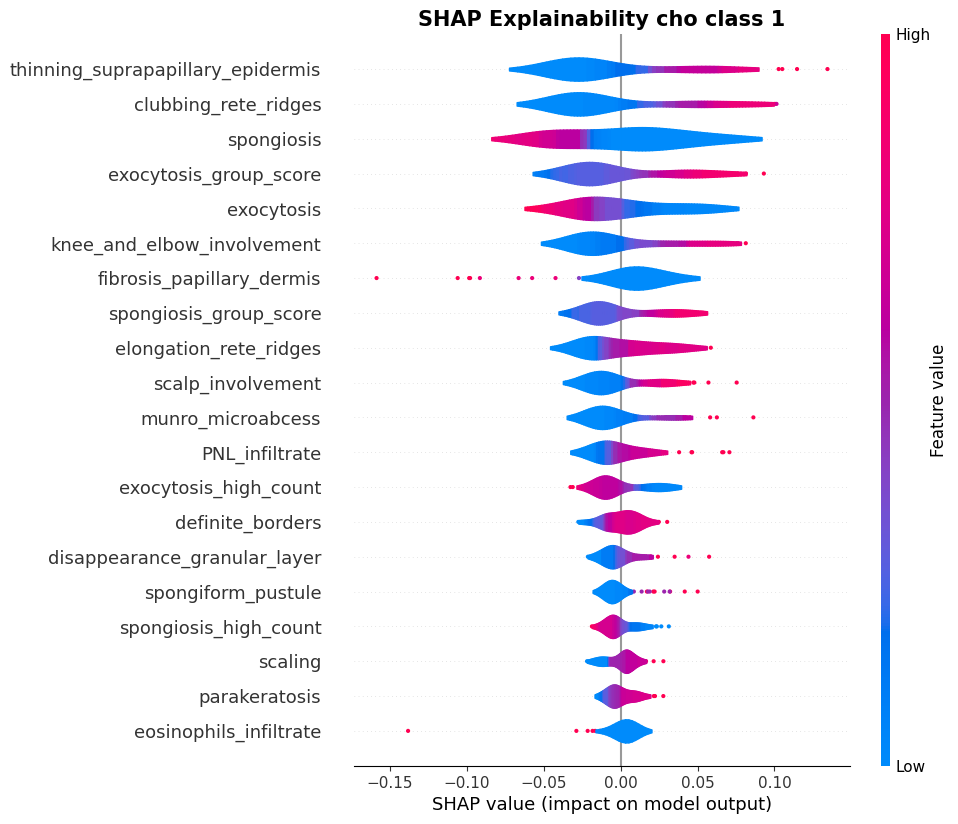

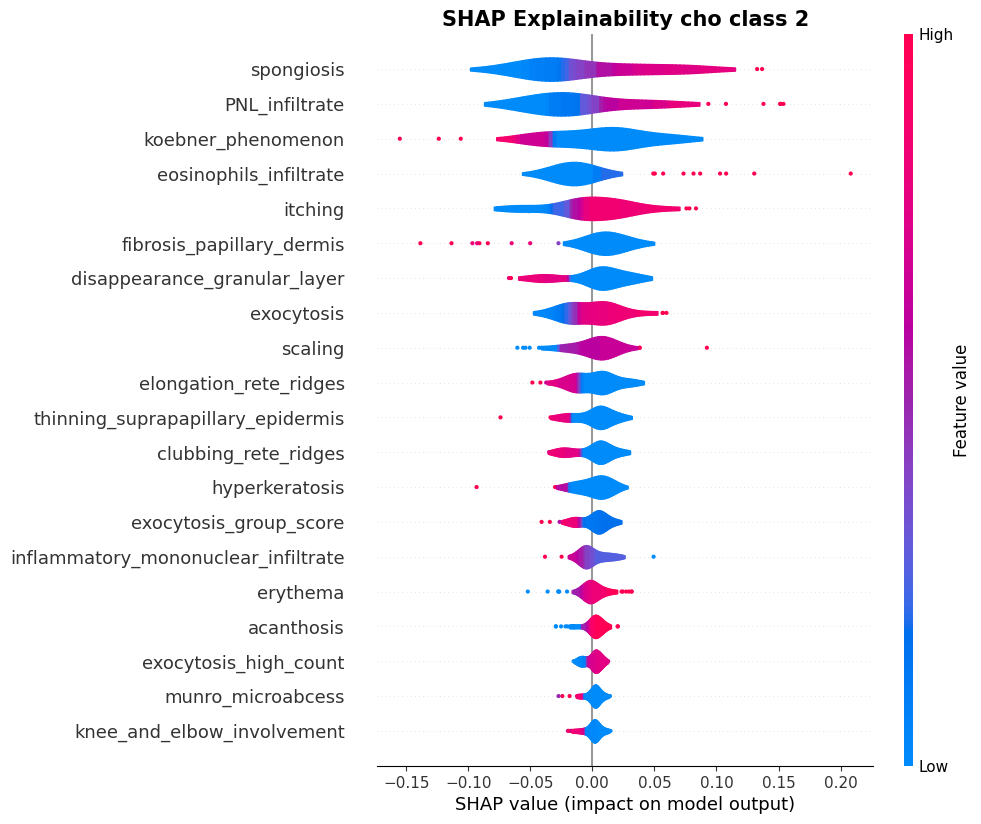

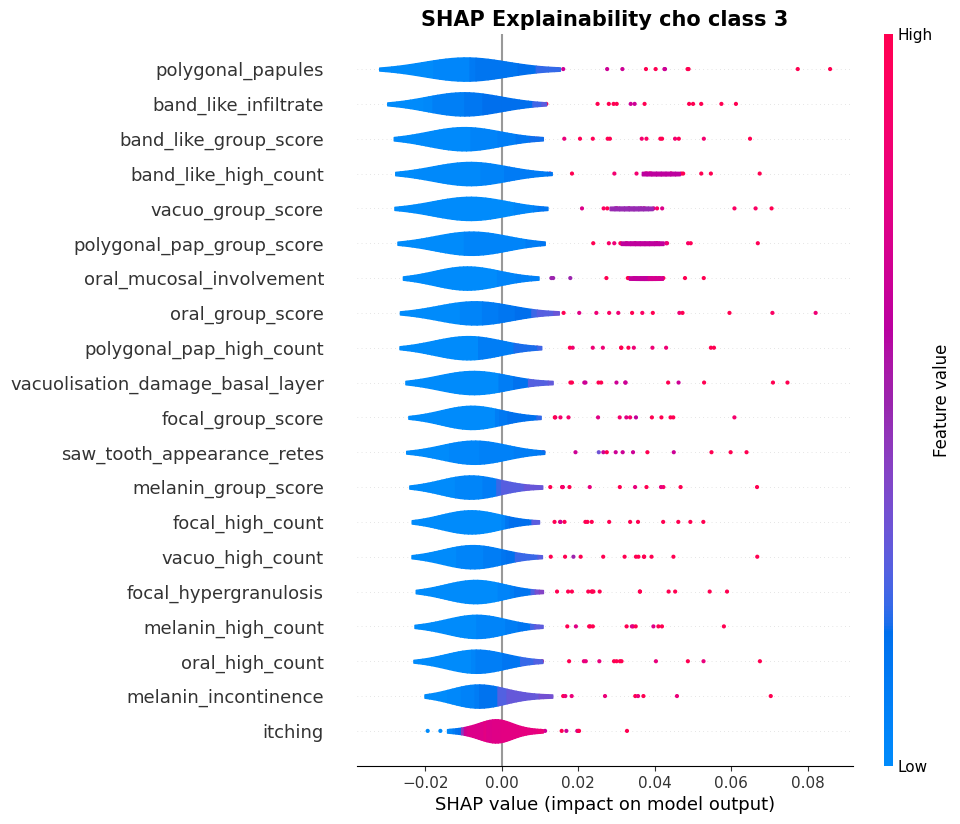

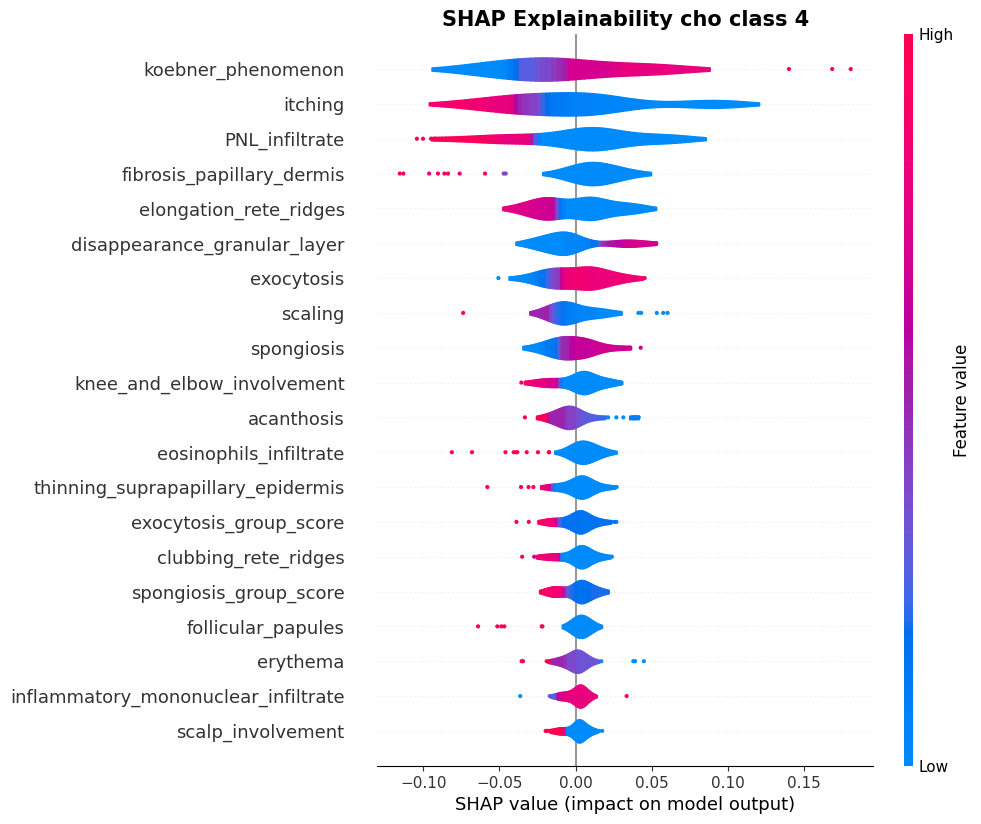

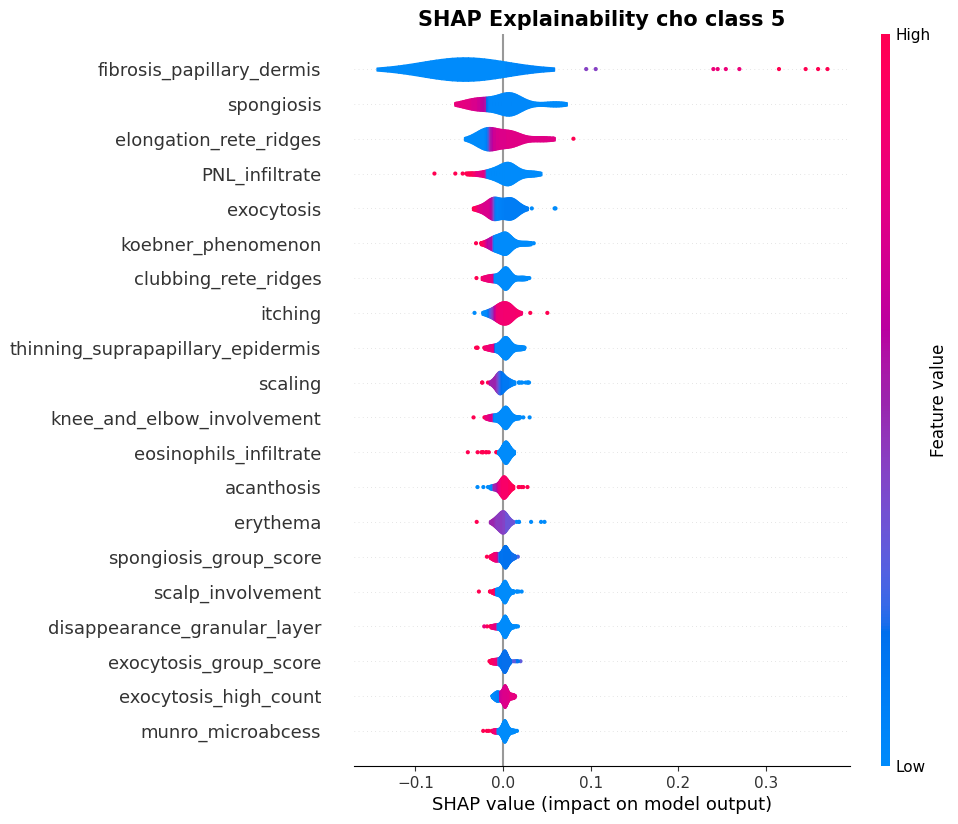

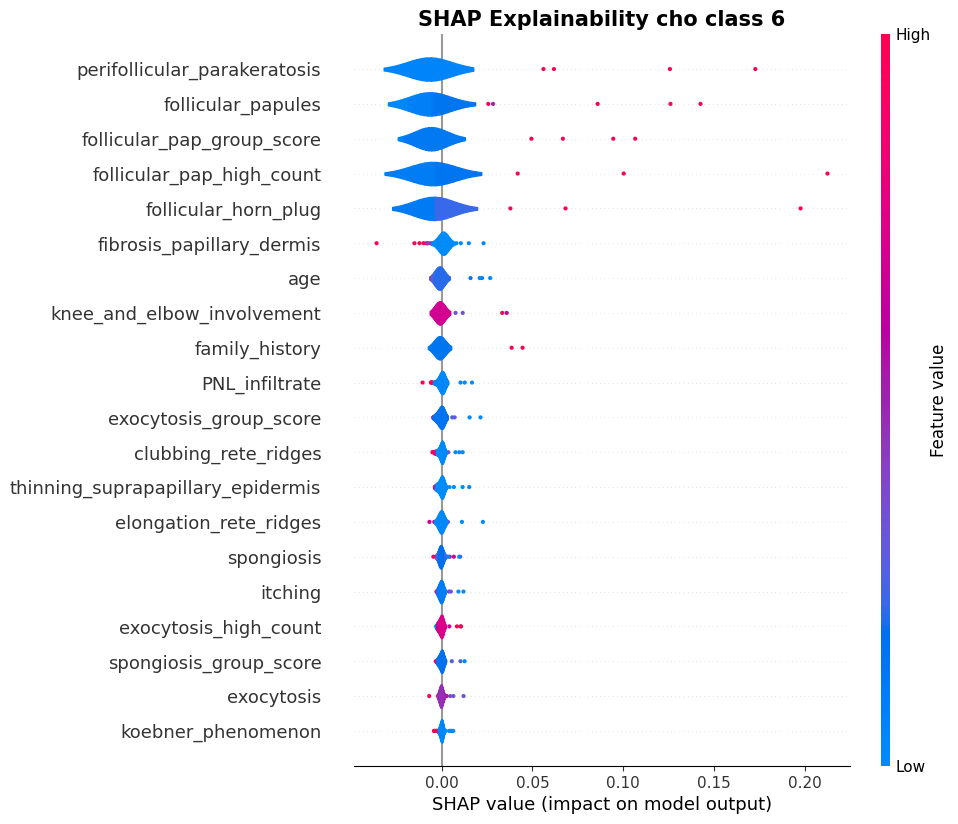

In [62]:
shap_exp = shap.Explanation(
    values=shap_values.values,
    base_values=shap_values.base_values,
    data=X_eng_test_processed,
    feature_names=feature_names
)

for i in range (len(classes)):
    plt.title(f"SHAP Explainability cho {str_classes[i]}", fontdict=font_dict)
    shap.plots.violin(shap_exp[:, :, i])

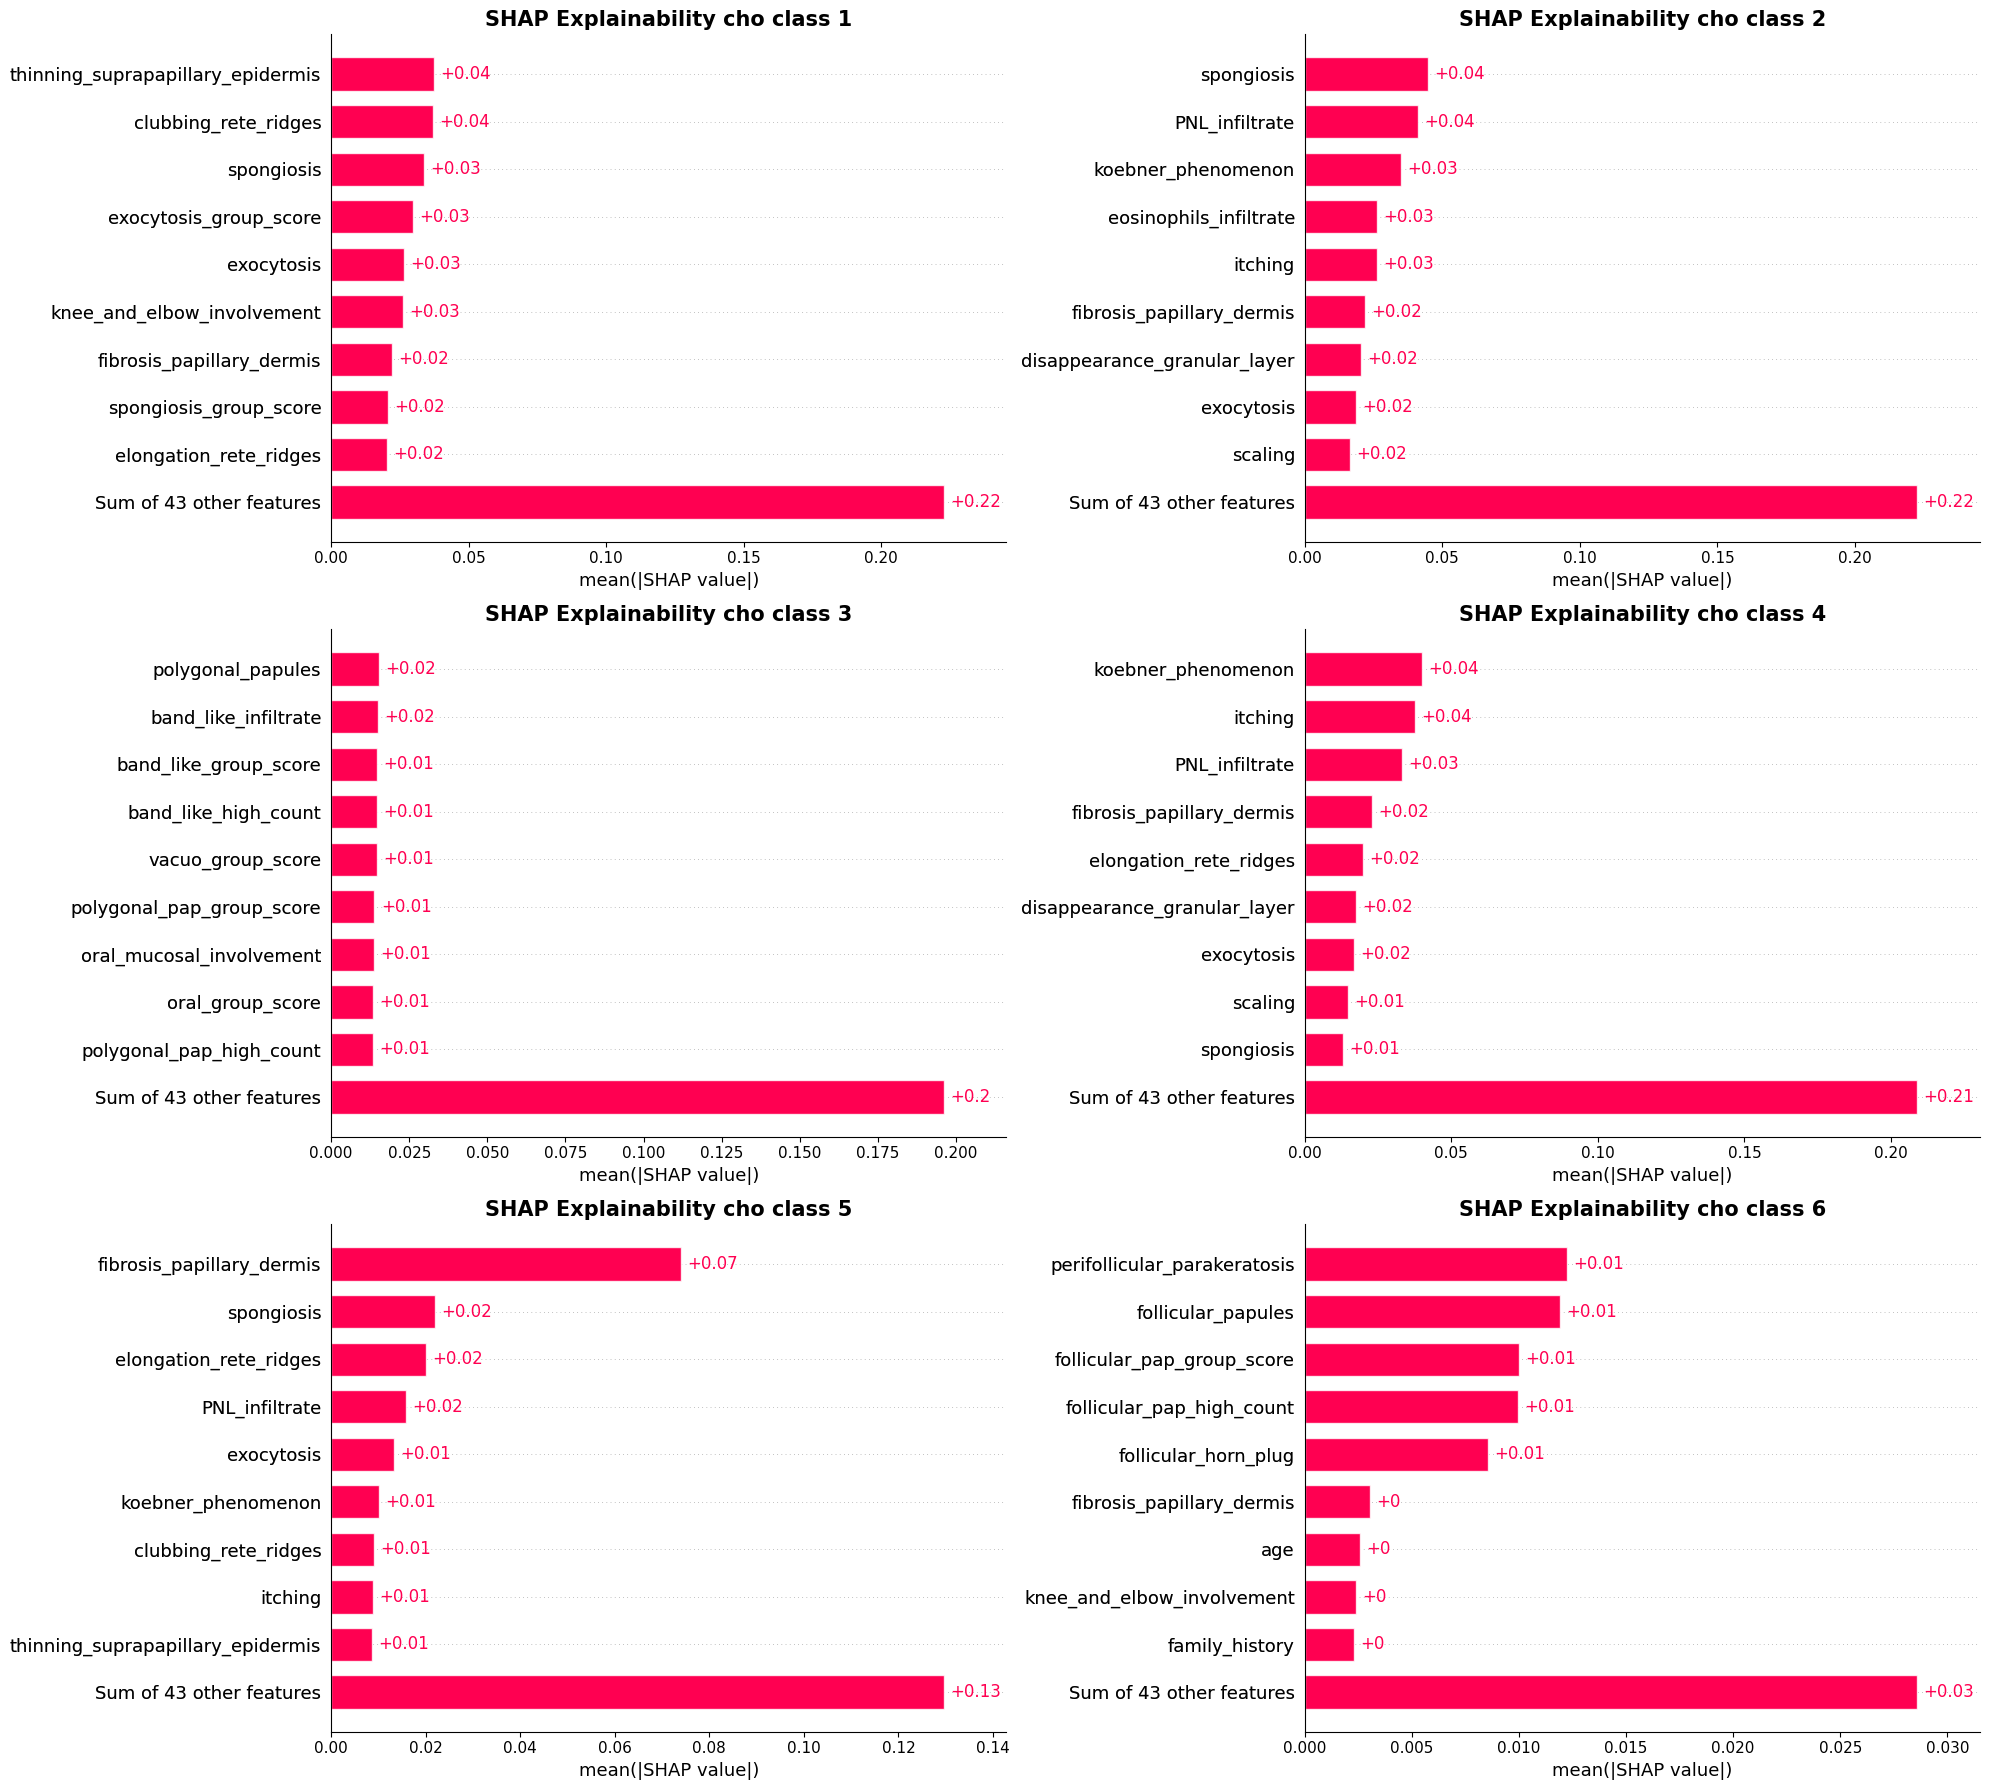

In [63]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20, 18))

for idx, class_name in enumerate(str_classes):
    ax = axes.flatten()[idx]
    shap.plots.bar(shap_exp[:, :, idx], ax=ax, show=False)
    ax.set_title(f"SHAP Explainability cho {class_name}", fontdict=font_dict)

plt.tight_layout()
plt.show()

> #### **Local Explainability SHAP**

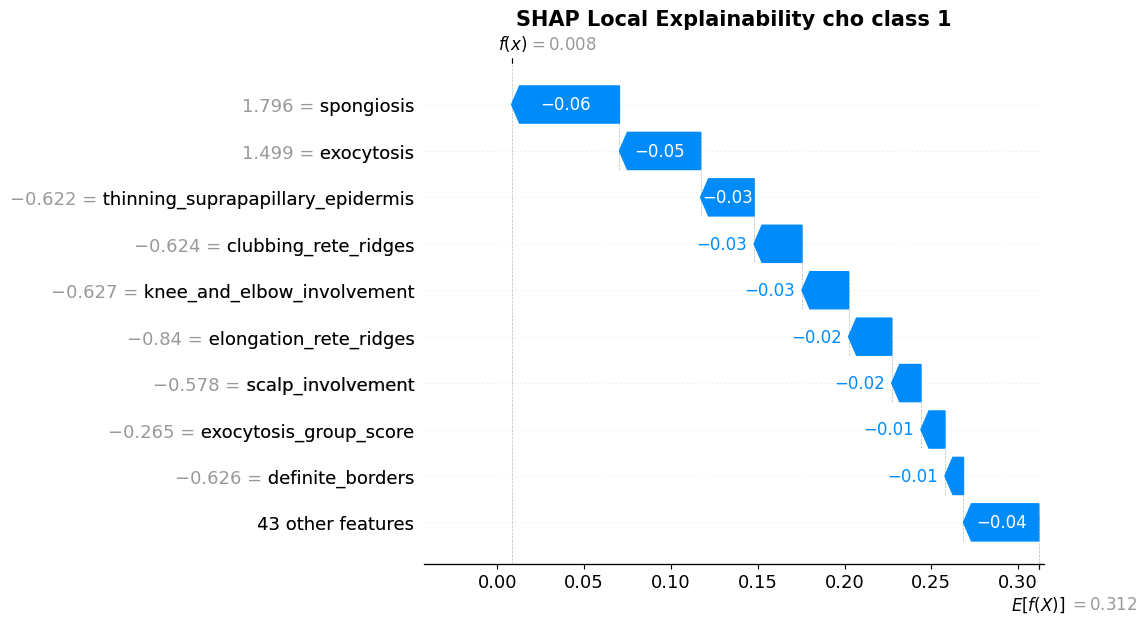

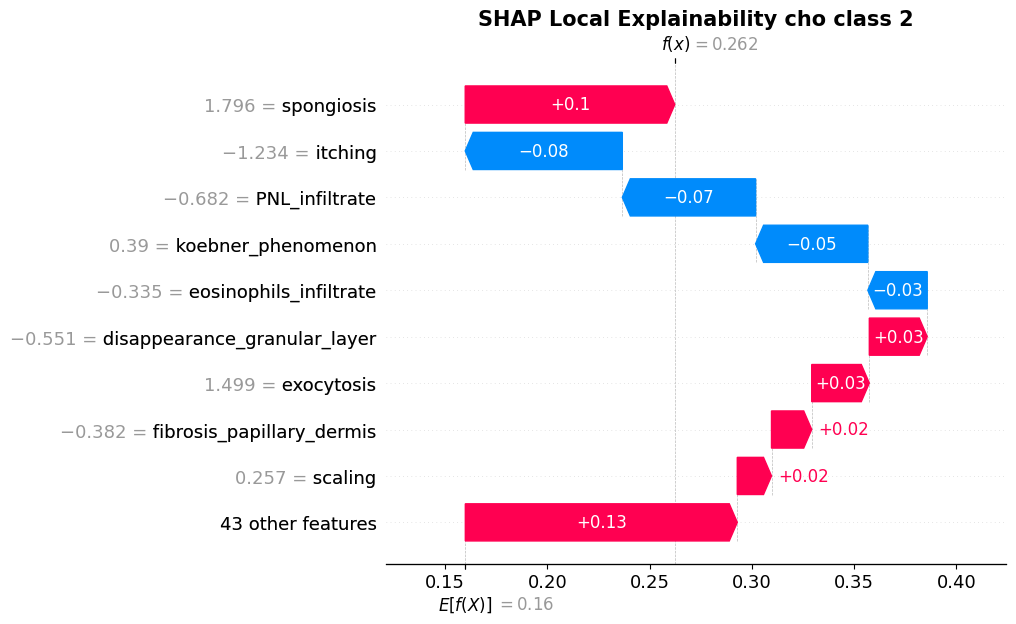

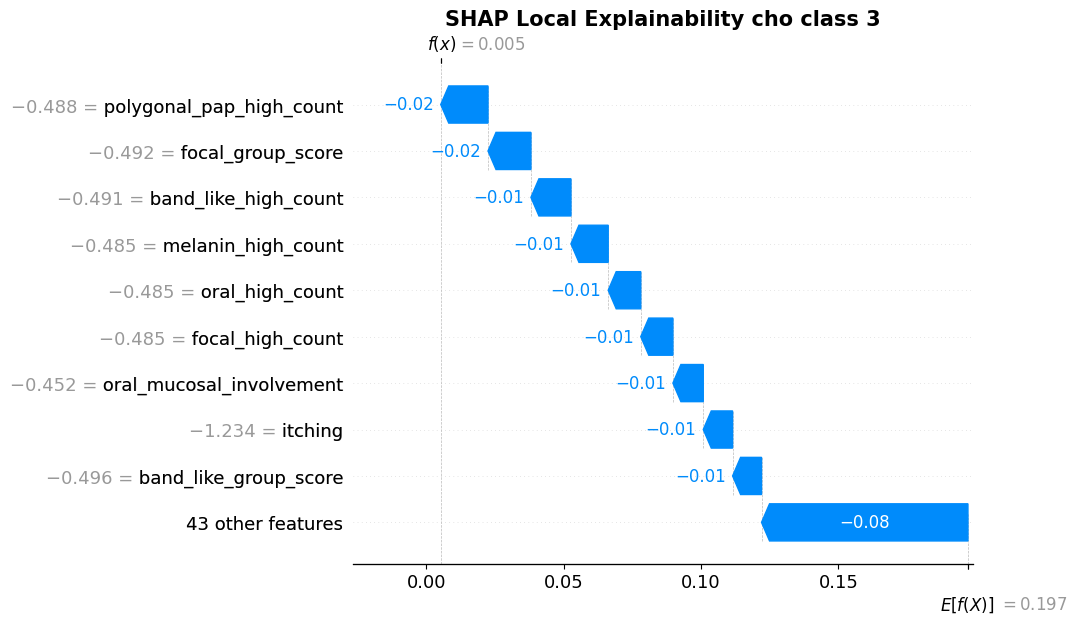

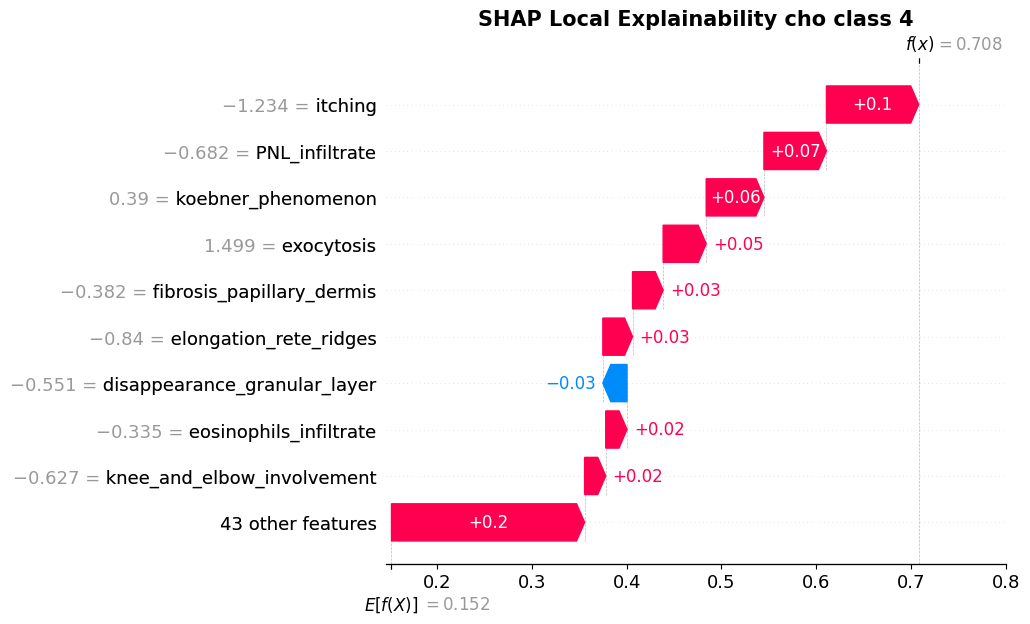

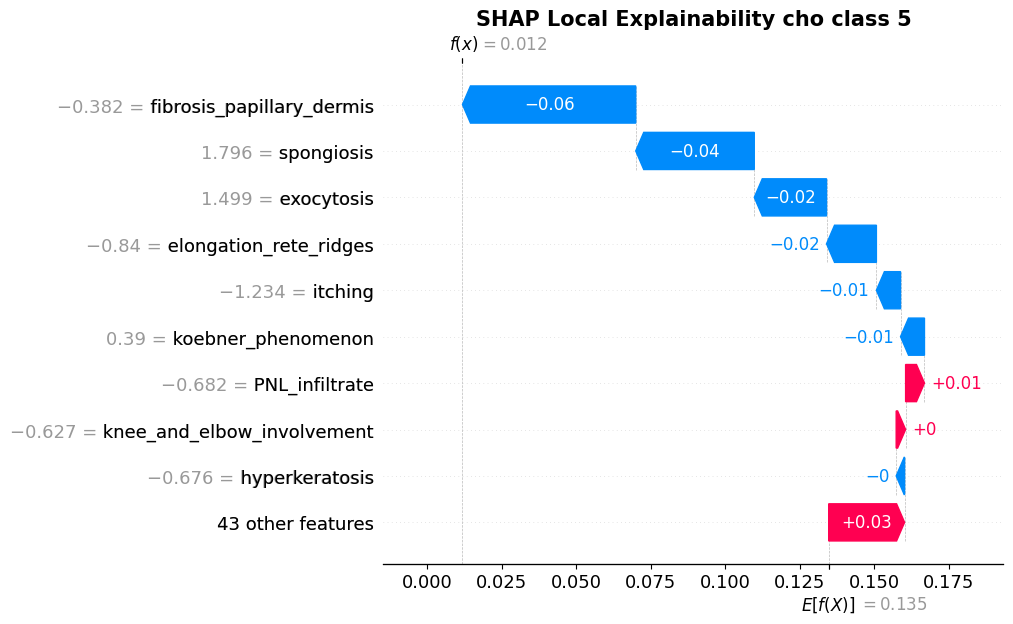

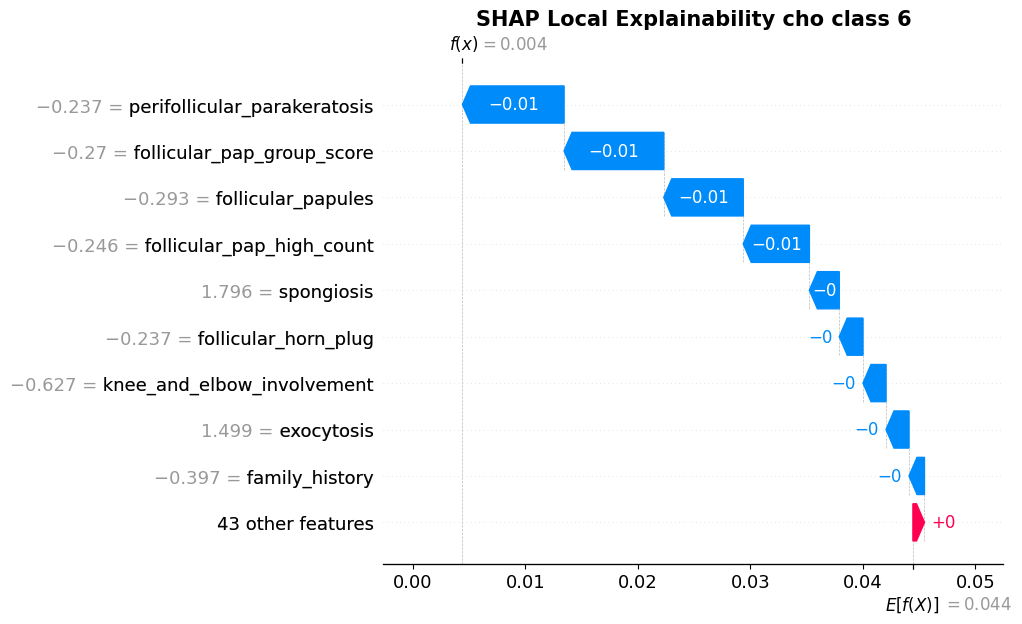

In [64]:
for idx, class_name in enumerate(str_classes):
    plt.figure(figsize=(18, 10))
    shap.plots.waterfall(shap_exp[1, :, idx], show=False, max_display=10)
    plt.title(f"SHAP Local Explainability cho {class_name}", fontdict=font_dict)
    plt.show()

> #### 💡 **Insights thu được:**
>
> **1. Global Explainability** - *violin plot:*
>
> |Class|Top Features|Điểm đáng chú ý|
> |---|---|---|
> |1|`thinning_suprapapillary_epidermis`, `clubbing_rete_ridges`, `spongiosis`, `exocytosis_group_score`|**Histopathological** nổi bật kèm theo nhóm điểm `exocytosis` *(feature engineering)*|
> |2|`spongiosis`, `PNL_infiltrate`, `koebner_phenomenon`, `elosinophils_infiltrate`|**Histopathological** + `spongiosis`, `PNL_infiltrate`  nổi bật nhất|
> |3|`PNL_infiltrate` (pattern ngược so với tất cả các feature khác)|**Histopathological** + **Clinical** với feature value thấp *(tức mức độ thấp)* đều đóng góp theo chiều âm của model cho `class 3`. Riêng `PNL_infiltrate` mang pattern trái ngược hoàn toàn.|
> |4|`koebner_phenomenon`, `itching`, `PNL_infiltrate`, `fibrosis_papillary_dermis`|**Histopathological** vẫn chiếm spotlight. `koebner_phenomenon`, `fibrosis_papillary_dermis` đều mang outliers đóng góp mạnh, lần lượt theo chiều dương và âm.|
> |5|`fibrosis_papillary_dermi` + một số feature mới qua *FE* (high_count, group_score)|**Histopathological** + `fibrosis_papillary_dermi` là feature khá nổi bật. Đa số các sample với mức độ `fibrosis_papillary_dermi` thấp đều đóng góp theo chiều âm cho `class 5` của model, nhưng lại chứa các outliers với đóng góp dương lơn **(> 0.4)** cho output. Một số feature qua *FE* cũng đã góp mặt nhưng không mang nhiều đóng góp.|
> |6|`follicular_papules`, `follicular_pap_group_scores`, `perifollicular_parakeratosis`, `follicular_pap_high_counta`|**Histopathological** + **Clinical**. Nhóm feature liên quan tới `follicular_papules` lại cho thấy pattern quan trọng của model trong việc predict `class 6`. Các sample của 4 biến *Top features* này đều chứa các outliers đóng góp theo chiều dương **(~ 0.10 - 0.25)**. Chứng tỏ nhóm `follicular_papules` mang signal mạnh cho `class 6`.|
>
> --- 
>
> #### → **Một vài insight nổi bật:**
> - **Class 1:** Các biến mô bệnh học cho thấy pattern nổi bật và hoàn toàn trùng khớp với `EDA` đã được discuss trước đó. `clubbing_rete_ridges` và `thinning_suprapapillary_epidermis` là 2 biến mang signal mạnh, khi feature value càng cao - tức là mức độ mô bệnh học đó càng rõ thì càng quan trọng trong việc đóng góp vào model predict `class 1`. Trái lại với đó là 2 biến `spongiosis`, `exocytosis` cho thấy pattern ngược lại hoàn toàn - mức độ càng rõ thì càng đóng góp âm vào model prediction. Một số biến *FE* cũng đã góp mặt trong danh sách.
>
> - **class 2:** Top các histopathological feature vẫn chiếm đa số, `spongiosis`, `PNL_infiltrate` nổi bật nhất. `eosinophils_infiltrate` còn là một feature mang nhiều outliers, các feature value cao đóng góp khá lớn vào output của model **(~ +0.22)**
>
> - **class 3:** Đây là một class cho thấy pattern khá độc đáo, các feature với value thấp có xu hướng đóng góp âm cho mô hình. Ngoài ra, các biến đều mang rất nhiều `outliers`, kéo model vào dự đoán `class 3`. Không chỉ vậy, `PNL_infiltrate` mức độ càng cao thì càng đẩy model ra xa khỏi class 3.
>
> - **class 4:** Trong top 4 features đầu, xuất hiện **1 Clinical Feature - itching** với dải đóng góp rộng nhất. `fibrosis_papillary_dermis` mang nhiều outliers đóng góp âm - **~ -0.11**
>
> - **class 5:** `fibrosis_papillary_dermis` là biến nổi bật nhất đối với `class 5` với nhiều outliers đóng góp dương cực lớn **(lên tới ~ +0.42)** vào model output cho class này. Các biến còn lại cho thấy đóng góp khá ít cả 2 chiều, chỉ khoảng **< 0.05**
>
> - **class 6**: Đây là *minority class* trong bài toán nhưng các *FE feature* lại mang nhiều signal cho nó nhất. Các biến liên quan tới `follicular_papules`, `score` và `high_count` của nhóm là *top contributor cho class 6*.
>
> --- 
>
> **2. Local Explainability** - *waterfall plot:*
>
> - Nếu `Global Explainability` trả lời cho câu hỏi: "Những đặc trưng (feature) nào có ảnh hưởng và quan trọng nhất đối với toàn bộ mô hình trên toàn bộ tập dữ liệu nói chung?". Thì `Local Explainability` sẽ giải thích cho cách model đưa ra dự đoán cho *một class cụ thể* - tại sao model lại dự đoán class này? Và các feature có xu hướng đóng góp như thế nào?
>
> -  Đối với sample này, model bắt đầu từ base value của Class 4. Các feature có SHAP dương đẩy dự đoán về phía Class 4, các feature có SHAP âm đẩy ra khỏi Class 4. Tổng hợp lại tạo ra output `f(x)` cho Class 4.
>
> - Phân tích sample:
>
>   * Những feature *thuộc ô màu đỏ và mang dấu dương* là những feature đang đóng góp theo chiều dương → Thúc đẩy model đưa ra dự báo rằng *sample* này thuộc vào `class 4`. Ngược lại, những feature *thuộc ô màu xanh dương và mang dấu âm* là những feature chống lại model → Đẩy model ra xa khỏi dự báo `class 4`. Đây chính là `Interpretability` cho **Local Explainability**.
>
>   * 🩺 ***Diễn giải y khoa*:** Ở sample này, biến **Clincal** (khám lâm sàng) lại là top feature trong việc predict `class 4` của model. Đặc điểm hồ sơ khám lâm sàng về tình trạng bị ngứa (itching) sẽ làm tăng khả năng model phân loại người đó vào `class 4`. Bên cạnh đó, các feature **mức độ của đặc điểm mô bệnh học** cũng không kém phần quan trọng như `PNL_infiltrate`, `koebner_phenomenon`, `elongation_rete_ridges`,... cũng đang hỗ trợ model predict `class 4`. Khi hiển thị `top 10 features`, biến `disappearance_granular_layer` có đóng góp theo chiều âm **(-0.03 điểm SHAP)** → Kéo model ra xa khỏi `class 4`.
>
> --- 

---

> ## 📊 **Phần 13: Executive Summary**
>
> ### **1. Tổng quan kết quả**
>
> Project được xây dựng nhằm giải quyết bài toán **phân loại 6 nhóm bệnh erythemato-squamous** dựa trên các đặc trưng lâm sàng và mô bệnh học. Sau quá trình Data Cleaning, EDA, Feature Engineering, xây dựng Pipeline, so sánh nhiều mô hình và Hyperparameter Tuning, **Logistic Regression** được lựa chọn làm mô hình cuối cùng.
>
> Mô hình được tối ưu bằng `RandomizedSearchCV` kết hợp `GridSearchCV` trên **Stratified 5-Fold Cross-Validation**, sử dụng **F1 Macro** làm metric chính nhằm đánh giá công bằng giữa các class. Kết quả tốt nhất đạt **F1 Macro = 0.9701** trên Cross-Validation. Bộ hyperparameter cuối cùng gồm `C ≈ 0.099155`, `solver = "newton-cg"` và `class_weight = None`.
>
> Trên **test set**, mô hình đạt:
>
> | Metric    | Macro Average | Weighted Average |
> | --------- | ------------: | ---------------: |
> | Precision |      **0.98** |         **0.99** |
> | Recall    |      **0.99** |         **0.99** |
> | F1-score  |      **0.98** |         **0.99** |
>
> Accuracy đạt **0.99**, cho thấy mô hình có khả năng phân loại rất tốt trên test set. Đáng chú ý, sự chênh lệch nhỏ giữa Macro và Weighted Average cho thấy hiệu năng không chỉ đến từ các class có nhiều sample mà tương đối đồng đều giữa các class.
>
> ### **2. Key Findings từ EDA và Modeling**
>
> Kết quả phân tích cho thấy các **histopathological features** đóng vai trò nổi bật trong việc phân biệt các nhóm bệnh. Điều này phù hợp với đặc điểm của bài toán khi các bệnh erythemato-squamous có nhiều biểu hiện lâm sàng tương đồng nhưng có thể khác nhau ở các đặc điểm mô bệnh học.
>
> Feature Engineering cũng cung cấp thêm signal cho một số class, đặc biệt là các biến `group_score` và `high_count`. Tuy nhiên, không phải tất cả feature engineering đều tạo ra đóng góp lớn; một số feature mới chỉ xuất hiện ở mức độ hạn chế trong nhóm các feature quan trọng.
>
> ### **3. Key Findings từ SHAP / XAI**
>
> SHAP cho thấy importance của feature thay đổi theo từng class thay vì tồn tại một tập feature duy nhất quyết định toàn bộ bài toán:
>
> * **Class 1:** `thinning_suprapapillary_epidermis` và `clubbing_rete_ridges` là các feature nổi bật. Mức độ cao của hai đặc trưng này có xu hướng đóng góp tích cực cho dự đoán class 1, trong khi `spongiosis` và `exocytosis` có xu hướng đóng góp theo chiều ngược lại.
> * **Class 2:** `spongiosis` và `PNL_infiltrate` nổi bật, cùng với `eosinophils_infiltrate` ở một số sample có mức đóng góp đáng kể.
> * **Class 3:** xuất hiện pattern khác biệt, trong đó nhiều feature có giá trị thấp đóng góp theo chiều âm; `PNL_infiltrate` có xu hướng ngược lại.
> * **Class 4:** `koebner_phenomenon`, `itching`, `PNL_infiltrate` và `fibrosis_papillary_dermis` nằm trong nhóm feature quan trọng.
> * **Class 5:** `fibrosis_papillary_dermis` là feature nổi bật nhất, với một số sample có mức đóng góp dương lớn.
> * **Class 6:** mặc dù là **minority class**, nhóm feature liên quan đến `follicular_papules`, `follicular_pap_group_score` và `follicular_pap_high_count` lại mang signal đáng chú ý cho việc nhận diện class này.
>
> Nhìn chung, SHAP cho thấy mô hình không chỉ dựa trên một vài clinical features mà khai thác đáng kể các **histopathological signals**, đồng thời một số feature được tạo ra thông qua Feature Engineering có thể bổ sung thông tin cho những class nhất định.
>
> ### **4. Limitations**
>
> Mặc dù hiệu năng trên test set rất cao, kết quả cần được diễn giải thận trọng vì dataset có **quy mô tương đối nhỏ, khoảng 270 samples**. Đây là một hạn chế quan trọng đối với khả năng generalize của mô hình sang những bệnh nhân mới hoặc dữ liệu từ nguồn khác.
>
> Ngoài ra, quá trình thử nghiệm cho thấy các phương pháp **Oversampling như SMOTE và Random Oversampling không cải thiện tính ổn định của mô hình**. Với kích thước dataset nhỏ, việc tạo thêm synthetic samples có thể tạo noise và khiến decision boundary kém ổn định, thậm chí làm tăng nguy cơ overfitting. Vì vậy, pipeline cuối cùng không sử dụng Oversampling.
>
> Learning Curve cho thấy validation performance có xu hướng hội tụ với training performance và độ biến động F1 giảm khi số lượng training samples tăng. Tuy nhiên, quy mô dữ liệu nhỏ vẫn là hạn chế cần được xem xét khi đánh giá khả năng tổng quát hóa của mô hình.
>
> Cuối cùng, SHAP chỉ giải thích **cách mô hình đang sử dụng các feature để đưa ra prediction**, không đồng nghĩa với việc các feature đó là nguyên nhân y khoa trực tiếp gây ra bệnh. Vì vậy, các kết quả XAI nên được xem như công cụ hỗ trợ diễn giải mô hình thay vì thay thế clinical diagnosis.
>
> ### **5. Recommendations**
>
> Dựa trên toàn bộ kết quả, các hướng phát triển tiếp theo được đề xuất:
>
> **1. Mở rộng dataset:**
> Thu thập thêm bệnh nhân từ nhiều nguồn và nhiều nhóm dân số khác nhau nhằm giảm ảnh hưởng của kích thước mẫu nhỏ và cải thiện khả năng generalization.
>
>
> **2. Ưu tiên chất lượng dữ liệu hơn Oversampling:**
> Vì SMOTE/ROS không cho thấy sự ổn định tốt trên dataset hiện tại, hướng phát triển nên tập trung vào việc thu thập thêm dữ liệu thực tế và cải thiện chất lượng labeling thay vì phụ thuộc quá nhiều vào synthetic samples.
>
> **3. Tiếp tục khai thác Clinical + Histopathological features:**
> Kết quả SHAP cho thấy histopathological features mang signal mạnh, trong khi một số clinical features vẫn đóng vai trò quan trọng đối với từng class. Do đó, việc kết hợp hai nhóm thông tin nên tiếp tục được duy trì.
>
> **4. Phát triển XAI sâu hơn:**
> Có thể mở rộng từ Global SHAP sang phân tích nhiều patient-level cases, đặc biệt tập trung vào các trường hợp mô hình dễ nhầm lẫn giữa các class, để đánh giá xem những pattern nào khiến prediction trở nên khó khăn.
>
> ---
>
> ### **Overall Conclusion**
>
> **The final Logistic Regression pipeline demonstrates strong classification performance and good class-wise balance on the available test data, achieving 0.99 accuracy and 0.98 macro F1-score.** Quan trọng hơn, kết quả từ EDA và SHAP cho thấy mô hình đang khai thác các pattern có ý nghĩa trong cả **clinical** và đặc biệt là **histopathological features**, trong đó một số Feature Engineering cũng cung cấp thêm signal cho các class cụ thể.
>
> Tuy nhiên, do dataset có quy mô nhỏ, kết quả hiện tại nên được xem là **strong proof-of-concept** hơn là một hệ thống chẩn đoán có thể triển khai trực tiếp. Bước phát triển quan trọng nhất không phải tiếp tục tối ưu mô hình trên dataset hiện tại, mà là **mở rộng dữ liệu, kiểm chứng trên external dataset và đánh giá khả năng generalization**.


---

## **Kết thúc bài toán y khoa - đưa ra khuyến nghị**
> #### **🧪 Medical / Clinical Recommendations**
>
> Kết quả của mô hình có thể được định hướng như một **clinical decision-support tool**, hỗ trợ bác sĩ trong quá trình phân loại ban đầu các nhóm bệnh erythemato-squamous. Tuy nhiên, prediction của mô hình **không nên được sử dụng như một chẩn đoán độc lập**. Quyết định cuối cùng cần dựa trên clinical examination, bệnh sử, đánh giá chuyên môn và khi cần thiết là kết quả mô bệnh học.
>
> Dựa trên đặc điểm của bài toán và các feature quan trọng được xác định bởi EDA và SHAP, có thể đề xuất quy trình hỗ trợ lâm sàng:
>
> **1. Đánh giá lâm sàng ban đầu**
>
> Bác sĩ nên thu thập có hệ thống các biểu hiện như mức độ ban đỏ (`erythema`), bong vảy (`scaling`), ngứa (`itching`), ranh giới tổn thương (`definite_borders`), hiện tượng Koebner, tổn thương vùng da đầu, đầu gối/khuỷu tay và các biểu hiện niêm mạc.
>
> Đây là những thông tin có thể cung cấp signal cho mô hình và đồng thời giúp bác sĩ định hướng chẩn đoán phân biệt.
>
> **2. Kết hợp với đánh giá mô bệnh học khi cần thiết**
>
> Vì nhiều **histopathological features** nằm trong nhóm feature quan trọng của mô hình, kết quả cho thấy thông tin mô bệnh học đóng vai trò đáng kể trong việc phân biệt các nhóm bệnh. Do đó, trong những trường hợp biểu hiện lâm sàng không đủ rõ ràng, cần cân nhắc đánh giá mô bệnh học theo chỉ định của bác sĩ chuyên khoa.
>
> **3. Sử dụng prediction như công cụ hỗ trợ, không thay thế bác sĩ**
>
> Khi mô hình đưa ra một prediction, đặc biệt trong những trường hợp có xác suất giữa nhiều class tương đối gần nhau, kết quả nên được xem là **một nguồn thông tin bổ sung**. Bác sĩ cần đối chiếu prediction với clinical findings và histopathological findings trước khi đưa ra diagnosis hoặc treatment plan.
>
> **4. Ưu tiên theo dõi các trường hợp khó phân loại**
>
> Các sample mà mô hình có confidence thấp hoặc dễ nhầm lẫn giữa các class nên được đánh dấu để thực hiện thêm clinical assessment hoặc diagnostic investigation thay vì đưa ra quyết định điều trị chỉ dựa trên prediction.
>
> **5. Điều trị cần được cá thể hóa theo diagnosis đã được xác nhận**
>
> Các nhóm bệnh erythemato-squamous có thể có biểu hiện tương tự nhau nhưng nguyên nhân, diễn tiến và phương pháp điều trị có thể khác nhau. Vì vậy, **không nên suy ra phương pháp điều trị trực tiếp từ prediction của Machine Learning model**. Sau khi diagnosis được xác nhận, bác sĩ da liễu sẽ lựa chọn treatment plan phù hợp với loại bệnh, mức độ tổn thương, vị trí tổn thương, triệu chứng và tình trạng cụ thể của bệnh nhân.
>
> **6. Theo dõi và đánh giá lại**
>
> Trong trường hợp clinical presentation thay đổi hoặc treatment response không phù hợp với diagnosis ban đầu, cần đánh giá lại bệnh nhân và xem xét lại diagnosis. Đây cũng có thể là nguồn dữ liệu có giá trị để phát triển các phiên bản model tiếp theo.
>
> ---
>
> ### **Clinical Implication**
>
> Giá trị thực tế tiềm năng của project không nằm ở việc để mô hình **“chẩn đoán và kê đơn thay bác sĩ”**, mà ở việc xây dựng một hệ thống có khả năng:
>
> **Patient data → Clinical + Histopathological assessment → ML-assisted classification → Explainable prediction → Clinician review → Confirmed diagnosis → Appropriate treatment**
>
> Do đó, hướng phát triển phù hợp nhất là biến mô hình thành một **explainable clinical decision-support system**, trong đó prediction đi kèm với các feature đóng góp chính thông qua XAI để bác sĩ có thể hiểu tại sao model đưa ra kết quả đó.
>
> --- 